---

## 1. Environment Setup & Data Loading

In [161]:
# Install dependencies

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.3.3
numpy: 2.3.5


In [162]:
# Load the data (setup local path to the data folder)

DATA_DIR = Path(r"C:\Users\dhita\OneDrive\Desktop\TCX3901_db\Olist-20260818T114028Z-1-001\Olist")

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
print(len(orders))  # expect 99441


99441


In [163]:
# Load the data (Overview to Seller Reliability Analysis only
TABLES = {
    "orders": ("olist_orders_dataset.csv", [
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]),
    "order_items": ("olist_order_items_dataset.csv", ["shipping_limit_date"]),
    "order_reviews": ("olist_order_reviews_dataset.csv", ["review_creation_date", "review_answer_timestamp"]),
    "sellers": ("olist_sellers_dataset.csv", None),
    "products": ("olist_products_dataset.csv", None),
}

olist = {}
for name, (filename, date_cols) in TABLES.items():
    olist[name] = pd.read_csv(os.path.join(DATA_DIR, filename), parse_dates=date_cols)

for name, df in olist.items():
    print(f"{name:15s} {df.shape[0]:>8,} rows x {df.shape[1]} cols")
    

orders            99,441 rows x 8 cols
order_items      112,650 rows x 7 cols
order_reviews     99,224 rows x 7 cols
sellers            3,095 rows x 4 cols
products          32,951 rows x 9 cols


## 2. Know your keys before you join anything

Two traps from the project handbook, checked here even though this is a seller-level problem:

- **`customer_id` vs `customer_unique_id`.** `customer_id` is generated fresh per order; it is not a person. This problem never joins `customers`, so it doesn't apply directly — but it would bite immediately if a customer-level feature were ever added later.
- **Target leakage.** `order_delivered_customer_date` and `order_delivered_carrier_date` define the lead-time outcome — they can only be used to *compute* the regression target, never as a predictor of it. Review timestamps are written after the experience, so they can't predict anything that happens before the review is left. Nothing in the feature set built below uses these columns as inputs; they're only used to derive the target itself (and, in Section 6, the on-time flag).


---

## 3. Individual Table Exploration (before join)

In [164]:
# Column-by-column summary: type, missing count/%, unique count
def field_summary(df, table_name):
    """Column-by-column summary: type, missing count/%, unique count."""
    def get_type(dtype):
        s = str(dtype)
        if "int" in s:
            return "integer"
        if "float" in s:
            return "decimal"
        if "datetime" in s:
            return "date/time"
        return "text"

    n = len(df)
    rows = []
    for col in df.columns:
        n_missing = df[col].isna().sum()
        pct_missing = f"{n_missing:,} ({n_missing / n:.2%})" if n_missing > 0 else "0"
        rows.append({
            "Column": col,
            "Type": get_type(df[col].dtype),
            "Missing": pct_missing,
            "Unique": f"{df[col].nunique():,}",
        })
    result = pd.DataFrame(rows)
    print(f"{table_name} — {n:,} rows x {df.shape[1]} cols")
    return result

### 3.1. Orders Table

In [165]:
# Orders table summary
field_summary(olist["orders"], "orders")

orders — 99,441 rows x 8 cols


,Column,Type,Missing,Unique
0,order_id,text,0,"99,441"
1,customer_id,text,0,"99,441"
2,order_status,text,0,8
3,order_purchase_timestamp,date/time,0,"98,875"
4,order_approved_at,date/time,160 (0.16%),"90,733"
5,order_delivered_carrier_date,date/time,"1,783 (1.79%)","81,018"
6,order_delivered_customer_date,date/time,"2,965 (2.98%)","95,664"
7,order_estimated_delivery_date,date/time,0,459


In [166]:
# Checking duplicate order_id
duplicate_orders = olist["orders"]["order_id"].duplicated().sum()

print(f"Duplicate order_id: {duplicate_orders:,}")

Duplicate order_id: 0


**Note**: 

order_id has no missing values and all 99,441 values are unique, so it is suitable as the primary join key for the Orders table

In [167]:
# Check order status distribution
olist["orders"]["order_status"].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 3.1.1. Missing Summary of order_approved_at

In [168]:
# Missing values in orders table (order_approved_at)
missing_approval = olist["orders"][olist["orders"]["order_approved_at"].isna()]
print("Order status breakdown:")
print(missing_approval["order_status"].value_counts())

Order status breakdown:
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64


In [169]:
# Canceled ones — limit to 10
canceled_missing = missing_approval[missing_approval["order_status"] == "canceled"]
print(f"Total canceled: {len(canceled_missing):,} (showing first 10)")
canceled_missing[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total canceled: 141 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,canceled,2018-09-20 13:54:16,NaT,NaT,2018-10-17
1868,df8282afe61008dc26c6c31011474d02,canceled,2017-03-04 12:14:30,NaT,NaT,2017-04-10
2029,8d4c637f1accf7a88a4555f02741e606,canceled,2018-08-29 16:27:49,NaT,NaT,2018-09-13
2161,7a9d4c7f9b068337875b95465330f2fc,canceled,2017-05-01 16:12:39,NaT,NaT,2017-05-30
3056,ddaec6fff982b13e7e048b627a11d6da,canceled,2016-10-04 19:41:32,NaT,NaT,2016-11-16
3094,5290c34bd38a8a095b885f13958db1e1,canceled,2018-08-21 10:25:18,NaT,NaT,2018-09-06
3684,03310aa823a66056268a3bab36e827fb,canceled,2018-08-07 16:33:59,NaT,NaT,2018-09-04
4373,4c8b9947280829d0a8b7e81cc249b875,canceled,2018-08-09 14:54:47,NaT,NaT,2018-08-21
4939,b13ea375fe9c728832688264638f84cf,canceled,2018-08-22 18:52:29,NaT,NaT,2018-09-19


In [170]:
# Delivered ones — show all 14 (the genuine status/timestamp contradiction)
delivered_missing = missing_approval[missing_approval["order_status"] == "delivered"]
print(f"Total delivered: {len(delivered_missing):,} (showing all)")
delivered_missing[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total delivered: 14 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22
48401,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16
61743,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20


In [171]:
# Created - show all 5
created_stalled = olist["orders"][
    (olist["orders"]["order_approved_at"].isna()) &
    (olist["orders"]["order_status"] == "created")
]

print(created_stalled[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]])

# Compare to the dataset's overall date range, to check if these are just "too recent"
print("Dataset purchase range:", olist["orders"]["order_purchase_timestamp"].min(),
      "to", olist["orders"]["order_purchase_timestamp"].max())

# Pull their actual payment records
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")

pay_detail = payments[payments["order_id"].isin(created_stalled["order_id"])]
print(pay_detail)

                               order_id order_status order_purchase_timestamp  \
7434   b5359909123fa03c50bdb0cfed07f098      created      2017-12-05 01:07:52   
9238   dba5062fbda3af4fb6c33b1e040ca38f      created      2018-02-09 17:21:04   
21441  7a4df5d8cff4090e541401a20a22bb80      created      2017-11-25 11:10:33   
55086  35de4050331c6c644cddc86f4f2d0d64      created      2017-12-05 01:07:58   
58958  90ab3e7d52544ec7bc3363c82689965f      created      2017-11-06 13:12:34   

      order_delivered_carrier_date order_delivered_customer_date  \
7434                           NaT                           NaT   
9238                           NaT                           NaT   
21441                          NaT                           NaT   
55086                          NaT                           NaT   
58958                          NaT                           NaT   

      order_estimated_delivery_date  
7434                     2018-01-11  
9238                     201


Dataset purchase range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
                               order_id  payment_sequential payment_type  \
26362  35de4050331c6c644cddc86f4f2d0d64                   1  credit_card   
41909  b5359909123fa03c50bdb0cfed07f098                   1  credit_card   
49542  7a4df5d8cff4090e541401a20a22bb80                   1       boleto   
68282  90ab3e7d52544ec7bc3363c82689965f                   1  credit_card   
95187  dba5062fbda3af4fb6c33b1e040ca38f                   1       boleto   

       payment_installments  payment_value  
26362                     7         105.87  
41909                    10         160.94  
49542                     1          37.84  
68282                     6         245.85  
95187                     1         137.60  


### 3.1.2. Missing Summary of order_delivered_carrier_date

In [172]:
# Missing values in orders table (order_delivered_carrier_date)
missing_carrier = olist["orders"][olist["orders"]["order_delivered_carrier_date"].isna()]
print("Order status breakdown:")
print(missing_carrier["order_status"].value_counts())

Order status breakdown:
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64


In [173]:
# Unavailable — limit to 10
unavailable_no_carrier = missing_carrier[missing_carrier["order_status"] == "unavailable"]
print(f"Total unavailable: {len(unavailable_no_carrier):,} (showing first 10)")
unavailable_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total unavailable: 609 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
266,8e24261a7e58791d10cb1bf9da94df5c,unavailable,2017-11-16 15:09:28,NaT,NaT,2017-12-05
586,c272bcd21c287498b4883c7512019702,unavailable,2018-01-31 11:31:37,NaT,NaT,2018-02-16
687,37553832a3a89c9b2db59701c357ca67,unavailable,2017-08-14 17:38:02,NaT,NaT,2017-09-05
737,d57e15fb07fd180f06ab3926b39edcd2,unavailable,2018-01-08 19:39:03,NaT,NaT,2018-02-06
1160,2f634e2cebf8c0283e7ef0989f77d217,unavailable,2017-09-27 20:55:33,NaT,NaT,2017-10-27
1579,ee0db22a8e742b752914016708470ec8,unavailable,2017-08-24 11:04:41,NaT,NaT,2017-09-18
1826,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,2017-11-30 07:48:24,NaT,NaT,2017-12-29
2148,9f3458f0433d4cfa472f4682654b8d49,unavailable,2017-07-18 23:36:55,NaT,NaT,2017-08-09
2296,f0df036e9be21fc238f131bbfcdde769,unavailable,2017-02-24 23:39:21,NaT,NaT,2017-04-07
2316,86f0bcd9b426a2c1022ae317c7f27be6,unavailable,2017-03-08 15:13:03,NaT,NaT,2017-03-29


In [174]:
## Canceled — limit to 10
canceled_no_carrier = missing_carrier[missing_carrier["order_status"] == "canceled"]
print(f"Total canceled: {len(canceled_no_carrier):,} (showing first 10)")
canceled_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total canceled: 550 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,canceled,2018-08-04 14:29:27,NaT,NaT,2018-08-14
1130,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,canceled,2018-09-20 13:54:16,NaT,NaT,2018-10-17
1811,0966b61e30c4a07edbd7523f59b3f3e4,canceled,2018-05-22 18:50:55,NaT,NaT,2018-07-03
1819,9021cf1919f615a121410790dcce848f,canceled,2018-07-04 16:05:56,NaT,NaT,2018-08-22
1868,df8282afe61008dc26c6c31011474d02,canceled,2017-03-04 12:14:30,NaT,NaT,2017-04-10
1971,a39d3db795a5cf4c8b6c9dd050f0d326,canceled,2017-03-13 16:12:24,NaT,NaT,2017-03-30
2029,8d4c637f1accf7a88a4555f02741e606,canceled,2018-08-29 16:27:49,NaT,NaT,2018-09-13
2161,7a9d4c7f9b068337875b95465330f2fc,canceled,2017-05-01 16:12:39,NaT,NaT,2017-05-30
2197,375f80ffc05feb35ce2680f1fa490575,canceled,2017-06-13 21:10:05,NaT,NaT,2017-07-06


In [175]:
# Invoiced — limit to 10
invoiced_no_carrier = missing_carrier[missing_carrier["order_status"] == "invoiced"]
print(f"Total invoiced: {len(invoiced_no_carrier):,} (showing first 10)")
invoiced_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total invoiced: 314 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaT,NaT,2017-05-09
103,0760a852e4e9d89eb77bf631eaaf1c84,invoiced,2018-08-03 17:44:42,NaT,NaT,2018-08-21
455,38b7efdf33dd5561f4f5d4f6e07b0414,invoiced,2017-08-01 18:17:41,NaT,NaT,2017-08-28
1833,51b0dccc8596ce37a930dff2d63a10a2,invoiced,2017-05-05 22:34:48,NaT,NaT,2017-06-06
2116,5504eaa5a86eb25fa666cf2e6b96c701,invoiced,2017-11-29 08:33:06,NaT,NaT,2017-12-20
2649,c3a6dc9afef5794ea4a867b5a18e0ad1,invoiced,2017-11-25 14:10:20,NaT,NaT,2017-12-19
2873,566c5bff1142c9d6003a83fd2e8ad1e5,invoiced,2017-11-23 18:03:23,NaT,NaT,2017-12-18
3121,b4c9f083bce61caf47fb38f9ba058bce,invoiced,2017-08-05 16:00:56,NaT,NaT,2017-08-30
3615,f029d5966aa03c87e17e2482f86202b1,invoiced,2017-10-23 21:44:36,NaT,NaT,2017-11-14
3983,6a828279d73f18174dd3b9c653d5213d,invoiced,2017-06-25 17:54:26,NaT,NaT,2017-07-14


In [176]:
# Processing — limit to 10
processing_no_carrier = missing_carrier[missing_carrier["order_status"] == "processing"]
print(f"Total processing: {len(processing_no_carrier):,} (showing first 10)")
processing_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total processing: 301 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
128,15bed8e2fec7fdbadb186b57c46c92f2,processing,2017-09-03 14:22:03,NaT,NaT,2017-10-03
324,d3c8851a6651eeff2f73b0e011ac45d0,processing,2016-10-05 22:44:13,NaT,NaT,2016-12-09
741,6a6c7d523fd59eb5bbefc007331af717,processing,2017-11-24 20:09:33,NaT,NaT,2017-12-20
1192,745e1d4a7f8c4b548881788d4113bb1d,processing,2017-11-17 06:34:36,NaT,NaT,2017-12-12
1516,1d52ba7197c7acebbb4f826f6585536f,processing,2017-02-13 18:32:55,NaT,NaT,2017-04-04
1582,d815bd2c2bdd79e4c0e0263caa986d66,processing,2017-03-15 10:30:17,NaT,NaT,2017-04-13
1604,52b828f13e08788433adad4a7d135779,processing,2018-05-05 22:32:38,NaT,NaT,2018-06-01
1619,56ab0ef6726f49b711b84ce62e305c7c,processing,2017-11-21 17:54:26,NaT,NaT,2017-12-13
2126,4ea3508e2de6e58640c0efe3ef758829,processing,2017-05-21 23:42:14,NaT,NaT,2017-06-21
2198,533e104c4193cf07d264603f7800fb71,processing,2017-02-06 15:33:57,NaT,NaT,2017-03-03


In [177]:
# Created — show all 5
created_no_carrier = missing_carrier[missing_carrier["order_status"] == "created"]
print(f"Total created: {len(created_no_carrier):,} (showing all)")
created_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total created: 5 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
7434,b5359909123fa03c50bdb0cfed07f098,created,2017-12-05 01:07:52,NaT,NaT,2018-01-11
9238,dba5062fbda3af4fb6c33b1e040ca38f,created,2018-02-09 17:21:04,NaT,NaT,2018-03-07
21441,7a4df5d8cff4090e541401a20a22bb80,created,2017-11-25 11:10:33,NaT,NaT,2017-12-12
55086,35de4050331c6c644cddc86f4f2d0d64,created,2017-12-05 01:07:58,NaT,NaT,2018-01-08
58958,90ab3e7d52544ec7bc3363c82689965f,created,2017-11-06 13:12:34,NaT,NaT,2017-12-01


In [178]:
# Approved — show all 2
approved_no_carrier = missing_carrier[missing_carrier["order_status"] == "approved"]
print(f"Total approved: {len(approved_no_carrier):,} (showing all)")
approved_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total approved: 2 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
44897,a2e4c44360b4a57bdff22f3a4630c173,approved,2017-02-06 20:18:17,NaT,NaT,2017-03-01
88457,132f1e724165a07f6362532bfb97486e,approved,2017-04-25 01:25:34,NaT,NaT,2017-05-22


In [179]:
# Delivered — show all 2 (the genuine status/timestamp contradiction)
delivered_no_carrier = missing_carrier[missing_carrier["order_status"] == "delivered"]
print(f"Total delivered: {len(delivered_no_carrier):,} (showing all)")
delivered_no_carrier[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total delivered: 2 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,delivered,2017-09-29 08:52:58,NaT,2017-11-20 19:44:47,2017-11-14
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,NaT,2017-06-23


### 3.1.3. Missing Summary of order_delivered_customer__date

In [180]:
# Missing values in orders table (order_delivered_customer_date)
missing_customer = olist["orders"][olist["orders"]["order_delivered_customer_date"].isna()]
print("Order status breakdown:")
print(missing_customer["order_status"].value_counts())

Order status breakdown:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [181]:
# Shipped — limit to 10
shipped_no_customer = missing_customer[missing_customer["order_status"] == "shipped"]
print(f"Total shipped: {len(shipped_no_customer):,} (showing first 10)")
shipped_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total shipped: 1,107 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
44,ee64d42b8cf066f35eac1cf57de1aa85,shipped,2018-06-04 16:44:48,2018-06-05 14:32:00,NaT,2018-06-28
154,6942b8da583c2f9957e990d028607019,shipped,2018-01-10 11:33:07,2018-01-11 19:39:23,NaT,2018-02-07
162,36530871a5e80138db53bcfd8a104d90,shipped,2017-05-09 11:48:37,2017-05-11 13:21:47,NaT,2017-06-08
231,4d630f57194f5aba1a3d12ce23e71cd9,shipped,2017-11-17 19:53:21,2017-11-22 17:28:34,NaT,2017-12-13
299,3b4ad687e7e5190db827e1ae5a8989dd,shipped,2018-06-28 12:52:15,2018-07-04 15:20:00,NaT,2018-08-03
305,b68d69564a79dea4776afa33d1d2fcab,shipped,2018-02-28 08:57:03,2018-03-05 16:10:13,NaT,2018-03-23
333,f373335aac9a659de916f7170b8bc07a,shipped,2018-03-17 15:32:31,2018-03-20 21:08:28,NaT,2018-04-13
374,5869074071e0f56e9085dc3742c97b2a,shipped,2018-06-08 20:06:48,2018-06-12 14:09:00,NaT,2018-06-28
430,6147a4d49752afd35a119d794e481588,shipped,2017-04-25 13:35:09,2017-05-02 15:29:33,NaT,2017-05-29
444,95e42e6aaf6264cd3e77c06b32dc3003,shipped,2017-11-24 09:23:33,2017-11-24 19:07:43,NaT,2017-12-08


In [182]:
# Canceled — limit to 10
canceled_no_customer = missing_customer[missing_customer["order_status"] == "canceled"]
print(f"Total canceled: {len(canceled_no_customer):,} (showing first 10)")
canceled_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total canceled: 619 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,canceled,2018-08-04 14:29:27,NaT,NaT,2018-08-14
613,714fb133a6730ab81fa1d3c1b2007291,canceled,2018-01-26 21:34:08,2018-01-29 22:33:25,NaT,2018-02-22
1058,3a129877493c8189c59c60eb71d97c29,canceled,2018-01-25 13:34:24,2018-01-26 21:42:18,NaT,2018-02-23
1130,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,NaT,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,canceled,2018-09-20 13:54:16,NaT,NaT,2018-10-17
1811,0966b61e30c4a07edbd7523f59b3f3e4,canceled,2018-05-22 18:50:55,NaT,NaT,2018-07-03
1819,9021cf1919f615a121410790dcce848f,canceled,2018-07-04 16:05:56,NaT,NaT,2018-08-22
1868,df8282afe61008dc26c6c31011474d02,canceled,2017-03-04 12:14:30,NaT,NaT,2017-04-10
1971,a39d3db795a5cf4c8b6c9dd050f0d326,canceled,2017-03-13 16:12:24,NaT,NaT,2017-03-30
2029,8d4c637f1accf7a88a4555f02741e606,canceled,2018-08-29 16:27:49,NaT,NaT,2018-09-13


In [183]:
# Unavailable — limit to 10
unavailable_no_customer = missing_customer[missing_customer["order_status"] == "unavailable"]
print(f"Total unavailable: {len(unavailable_no_customer):,} (showing first 10)")
unavailable_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total unavailable: 609 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
266,8e24261a7e58791d10cb1bf9da94df5c,unavailable,2017-11-16 15:09:28,NaT,NaT,2017-12-05
586,c272bcd21c287498b4883c7512019702,unavailable,2018-01-31 11:31:37,NaT,NaT,2018-02-16
687,37553832a3a89c9b2db59701c357ca67,unavailable,2017-08-14 17:38:02,NaT,NaT,2017-09-05
737,d57e15fb07fd180f06ab3926b39edcd2,unavailable,2018-01-08 19:39:03,NaT,NaT,2018-02-06
1160,2f634e2cebf8c0283e7ef0989f77d217,unavailable,2017-09-27 20:55:33,NaT,NaT,2017-10-27
1579,ee0db22a8e742b752914016708470ec8,unavailable,2017-08-24 11:04:41,NaT,NaT,2017-09-18
1826,6ad57aecbae806a7e9cc2cdb6b380711,unavailable,2017-11-30 07:48:24,NaT,NaT,2017-12-29
2148,9f3458f0433d4cfa472f4682654b8d49,unavailable,2017-07-18 23:36:55,NaT,NaT,2017-08-09
2296,f0df036e9be21fc238f131bbfcdde769,unavailable,2017-02-24 23:39:21,NaT,NaT,2017-04-07
2316,86f0bcd9b426a2c1022ae317c7f27be6,unavailable,2017-03-08 15:13:03,NaT,NaT,2017-03-29


In [184]:
# Invoiced — limit to 10
invoiced_no_customer = missing_customer[missing_customer["order_status"] == "invoiced"]
print(f"Total invoiced: {len(invoiced_no_customer):,} (showing first 10)")
invoiced_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total invoiced: 314 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaT,NaT,2017-05-09
103,0760a852e4e9d89eb77bf631eaaf1c84,invoiced,2018-08-03 17:44:42,NaT,NaT,2018-08-21
455,38b7efdf33dd5561f4f5d4f6e07b0414,invoiced,2017-08-01 18:17:41,NaT,NaT,2017-08-28
1833,51b0dccc8596ce37a930dff2d63a10a2,invoiced,2017-05-05 22:34:48,NaT,NaT,2017-06-06
2116,5504eaa5a86eb25fa666cf2e6b96c701,invoiced,2017-11-29 08:33:06,NaT,NaT,2017-12-20
2649,c3a6dc9afef5794ea4a867b5a18e0ad1,invoiced,2017-11-25 14:10:20,NaT,NaT,2017-12-19
2873,566c5bff1142c9d6003a83fd2e8ad1e5,invoiced,2017-11-23 18:03:23,NaT,NaT,2017-12-18
3121,b4c9f083bce61caf47fb38f9ba058bce,invoiced,2017-08-05 16:00:56,NaT,NaT,2017-08-30
3615,f029d5966aa03c87e17e2482f86202b1,invoiced,2017-10-23 21:44:36,NaT,NaT,2017-11-14
3983,6a828279d73f18174dd3b9c653d5213d,invoiced,2017-06-25 17:54:26,NaT,NaT,2017-07-14


In [185]:
# Processing — limit to 10
processing_no_customer = missing_customer[missing_customer["order_status"] == "processing"]
print(f"Total processing: {len(processing_no_customer):,} (showing first 10)")
processing_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head(10)

Total processing: 301 (showing first 10)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
128,15bed8e2fec7fdbadb186b57c46c92f2,processing,2017-09-03 14:22:03,NaT,NaT,2017-10-03
324,d3c8851a6651eeff2f73b0e011ac45d0,processing,2016-10-05 22:44:13,NaT,NaT,2016-12-09
741,6a6c7d523fd59eb5bbefc007331af717,processing,2017-11-24 20:09:33,NaT,NaT,2017-12-20
1192,745e1d4a7f8c4b548881788d4113bb1d,processing,2017-11-17 06:34:36,NaT,NaT,2017-12-12
1516,1d52ba7197c7acebbb4f826f6585536f,processing,2017-02-13 18:32:55,NaT,NaT,2017-04-04
1582,d815bd2c2bdd79e4c0e0263caa986d66,processing,2017-03-15 10:30:17,NaT,NaT,2017-04-13
1604,52b828f13e08788433adad4a7d135779,processing,2018-05-05 22:32:38,NaT,NaT,2018-06-01
1619,56ab0ef6726f49b711b84ce62e305c7c,processing,2017-11-21 17:54:26,NaT,NaT,2017-12-13
2126,4ea3508e2de6e58640c0efe3ef758829,processing,2017-05-21 23:42:14,NaT,NaT,2017-06-21
2198,533e104c4193cf07d264603f7800fb71,processing,2017-02-06 15:33:57,NaT,NaT,2017-03-03


In [186]:
# Delivered — show all 8 (the genuine status/timestamp contradiction)
delivered_no_customer = missing_customer[missing_customer["order_status"] == "delivered"]
print(f"Total delivered: {len(delivered_no_customer):,} (showing all)")
delivered_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total delivered: 8 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-07-03 19:26:00,NaT,2018-07-19


**Note:**
The above mentioned are the delivered orders with no customer delivery timestamp. We'll do checking in reverse direction for status/time stamp contradiction (non-delivered orders that do have a customer date). It means that the package physically completed its journey but the status was never updated to match.

In [187]:
# Non-delivered orders that nevertheless have a customer delivery timestamp
not_delivered_with_date = olist["orders"][
    (olist["orders"]["order_status"] != "delivered") &
    (olist["orders"]["order_delivered_customer_date"].notna())
]

print("Not marked delivered but customer delivery timestamp exists:", len(not_delivered_with_date))
print(not_delivered_with_date["order_status"].value_counts())
not_delivered_with_date[[
    "order_id", "order_status", "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date"
]]

Not marked delivered but customer delivery timestamp exists: 6
order_status
canceled    6
Name: count, dtype: int64


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
2921,1950d777989f6a877539f53795b4c3c3,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51
8791,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59
58266,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11
59332,8beb59392e21af5eb9547ae1a9938d06,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43
92636,65d1e226dfaeb8cdc42f665422522d14,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50


***Summary of Contradiction:***
- The 8 "delivered" orders missing a customer date — contradiction, because "delivered" implies the customer date should exist, but it doesn't.

- The 6 "canceled" orders with a full carrier + customer date — contradiction, because "canceled" implies the order never completed, but it clearly did.

In [188]:
# Created — show all 5
created_no_customer = missing_customer[missing_customer["order_status"] == "created"]
print(f"Total created: {len(created_no_customer):,} (showing all)")
created_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total created: 5 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
7434,b5359909123fa03c50bdb0cfed07f098,created,2017-12-05 01:07:52,NaT,NaT,2018-01-11
9238,dba5062fbda3af4fb6c33b1e040ca38f,created,2018-02-09 17:21:04,NaT,NaT,2018-03-07
21441,7a4df5d8cff4090e541401a20a22bb80,created,2017-11-25 11:10:33,NaT,NaT,2017-12-12
55086,35de4050331c6c644cddc86f4f2d0d64,created,2017-12-05 01:07:58,NaT,NaT,2018-01-08
58958,90ab3e7d52544ec7bc3363c82689965f,created,2017-11-06 13:12:34,NaT,NaT,2017-12-01


In [189]:
# Approved — show all 2
approved_no_customer = missing_customer[missing_customer["order_status"] == "approved"]
print(f"Total approved: {len(approved_no_customer):,} (showing all)")
approved_no_customer[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

Total approved: 2 (showing all)


,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
44897,a2e4c44360b4a57bdff22f3a4630c173,approved,2017-02-06 20:18:17,NaT,NaT,2017-03-01
88457,132f1e724165a07f6362532bfb97486e,approved,2017-04-25 01:25:34,NaT,NaT,2017-05-22


### 3.2 Order_Items Table

In [190]:
# Order items table summary
field_summary(olist["order_items"], "order_items")

order_items — 112,650 rows x 7 cols


,Column,Type,Missing,Unique
0,order_id,text,0,"98,666"
1,order_item_id,integer,0,21
2,product_id,text,0,"32,951"
3,seller_id,text,0,"3,095"
4,shipping_limit_date,date/time,0,"93,318"
5,price,decimal,0,"5,968"
6,freight_value,decimal,0,"6,999"


### 3.3 Order_Reviews Table

In [191]:
# Order reviews table summary
field_summary(olist["order_reviews"], "order_reviews")

order_reviews — 99,224 rows x 7 cols


,Column,Type,Missing,Unique
0,review_id,text,0,"98,410"
1,order_id,text,0,"98,673"
2,review_score,integer,0,5
3,review_comment_title,text,"87,656 (88.34%)","4,527"
4,review_comment_message,text,"58,247 (58.70%)","36,159"
5,review_creation_date,date/time,0,636
6,review_answer_timestamp,date/time,0,"98,248"


In [192]:
# Missing values in order reviews table
reviews = olist["order_reviews"]

print("Missing values per column:")
print(reviews.isna().sum())

Missing values per column:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [193]:
# Breakdown — how the two missing comment fields overlap
title_missing = reviews["review_comment_title"].isna()
message_missing = reviews["review_comment_message"].isna()

print("Missing title only:", (title_missing & ~message_missing).sum())
print("Missing message only:", (~title_missing & message_missing).sum())
print("Missing both:", (title_missing & message_missing).sum())
print("Missing neither (has both):", (~title_missing & ~message_missing).sum())

Missing title only: 31138
Missing message only: 1729
Missing both: 56518
Missing neither (has both): 9839


In [194]:
# Pulling a sample of each group (limit at 10)
comment_groups = [
    ("both_missing", title_missing & message_missing),
    ("title_only", title_missing & ~message_missing),
    ("message_only", ~title_missing & message_missing),
    ("neither_missing", ~title_missing & ~message_missing),
]

for label, mask in comment_groups:
    subset = reviews[mask]
    print(f"Total {label}: {len(subset):,} (showing first 10)")
    display(subset[[
        "review_id", "order_id", "review_score",
        "review_comment_title", "review_comment_message"
    ]].head(10))

Total both_missing: 56,518 (showing first 10)


,review_id,order_id,review_score,review_comment_title,review_comment_message
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN
10,c9cfd2d5ab5911836ababae136c3a10c,cdf9aa68e72324eeb25c7de974696ee2,5,NaN,NaN
11,96052551d87e5f62e6c9f6974ec392e9,3d374c9e46530bb5ed4a7648915306a6,5,NaN,NaN
13,23f75a37effc35d9a915b4e1ad483793,2eaf8e099d871cd5c22b83b5ea8f6e0e,4,NaN,NaN


Total title_only: 31,138 (showing first 10)


,review_id,order_id,review_score,review_comment_title,review_comment_message
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
24,0e0190b9db53b689b285d3f3916f8441,79832b7cb59ac6f887088ffd686e1d5e,5,NaN,obrigado pela atençao amim dispensada
27,fe3db7c069d694bab50cc43463f91608,2ca73e2ff9e3a186ad1e1ffb9b1d9c10,5,NaN,A compra foi realizada facilmente.\r\nA entreg...
28,e07eee7ad7666276bd8b27fbd83fd1ff,68b3cbc68e4cd1fe19bec35f1d3bb7ee,5,NaN,relógio muito bonito e barato.
29,2c5e27fc178bde7ac173c9c62c31b070,0ce9a24111d850192a933fcaab6fbad3,1,NaN,Não gostei ! Comprei gato por lebre
32,58044bca115705a48fe0e00a21390c54,68e55ca79d04a79f20d4bfc0146f4b66,1,NaN,Sempre compro pela Internet e a entrega ocorre...
37,2170c9452c2216457b36003fe2969fbb,af32671d0b8ce510a94d9111d97371d3,5,NaN,muito boa


Total message_only: 1,729 (showing first 10)


,review_id,order_id,review_score,review_comment_title,review_comment_message
53,1edd1a85161468a77e5fcb165be9b294,d8e17cc85323061493b16b68a130bcff,5,Ótimo,NaN
104,352609f0f2d34ce5d3b8de817ee948d5,96b947c986b42f213c9e6b8ccccedb89,3,Não recebi o produto.,NaN
220,a89a2b0c2014bc49a0f87f1eedb7b269,22b1eef278d4416c1e867a55d1c39fea,5,Entrega antes do previsto,NaN
225,cdc5c81bd9377ccbf9cb95f05648c31b,18956b40b774d6384c8539cd61784bd7,5,Recomendo,NaN
495,b50001aa0bbd7557c4ad80eee167a2a1,daece90b61801c766fe21e0922574566,5,Ótimo,NaN
521,cf1917bdb6925187eb7886ad0a11e745,62b2adbcbcf4e28df4b998bfb094f3f9,4,bom,NaN
583,3814f35a6ebd64d27e2130f30ec05255,19d1e5344936559f5f7b21099fdadd0e,4,5,NaN
598,057c9a1e8e767d8bf6fa59ac43a82435,0adf68e8a310f18fc7e75cffa60901b2,4,4,NaN
631,035cdc5e7ad5192da517cd947ed17a98,355c14cca8fef764ee4faa28db69342f,5,Excelente Loja,NaN
677,d759baf5b86943cc94607ca678da40f4,8821146ecf8a1eb441aa052b371f1814,5,ótimo,NaN


Total neither_missing: 9,839 (showing first 10)


,review_id,order_id,review_score,review_comment_title,review_comment_message
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes..."
19,373cbeecea8286a2b66c97b1b157ec46,583174fbe37d3d5f0d6661be3aad1786,1,Não chegou meu produto,Péssimo
22,d21bbc789670eab777d27372ab9094cc,4fc44d78867142c627497b60a7e0228a,5,Ótimo,Loja nota 10
34,c92cdd7dd544a01aa35137f901669cdf,37e7875cdce5a9e5b3a692971f370151,4,Muito bom.,Recebi exatamente o que esperava. As demais en...
36,08c9d79ec0eba1d252e3f52f14b8e6a9,e029f708df3cc108b3264558771605c6,5,Bom,"Recomendo ,"
38,b193ff3c9f32a01f3a0d9ae26b94d244,e2e6ee1ed2d7f2f36b05d234983bd7a0,5,Maravilhoso!,"Tô completamente apaixonada, loja super respon..."
43,86c5cfa7fcbde303f704b60a78ced7d6,a6456e781cb962cc3f412b04de4fed7b,5,Entrega perfeita,Muito bom. muito cheiroso.
59,500c05500aa275953129f49799ee5c73,8a9424899aac432d80d8e580932b5ee9,5,MT lindo,MT lindo
67,109b5ce2dd11bb8460eff3b86da6fefc,25362fbf6aac4b01a28dee1e076acc26,5,Ótimo Produto!,Recomendo o vendedor...


In [195]:
# Does leaving both fields blank relate to the star rating given?
both_blank_rate = reviews.groupby("review_score").apply(
    lambda g: (g["review_comment_title"].isna() & g["review_comment_message"].isna()).mean()
)
print("Share leaving BOTH fields blank, by review_score:")
print(both_blank_rate)

Share leaving BOTH fields blank, by review_score:
review_score
1   0.23
2   0.31
3   0.55
4   0.67
5   0.62
dtype: float64


In [196]:
# How many reviews leave both fields blank overall, vs. fill in both?
total_reviews = len(reviews)
both_blank = (reviews["review_comment_title"].isna() & reviews["review_comment_message"].isna()).sum()
both_filled = (reviews["review_comment_title"].notna() & reviews["review_comment_message"].notna()).sum()

print(f"Total reviews: {total_reviews:,}")
print(f"Leave BOTH fields blank: {both_blank:,} ({both_blank/total_reviews:.1%})")
print(f"Fill in BOTH fields: {both_filled:,} ({both_filled/total_reviews:.1%})")

Total reviews: 99,224
Leave BOTH fields blank: 56,518 (57.0%)
Fill in BOTH fields: 9,839 (9.9%)


Most reviewers don't write anything: 56,518 reviews (57.0%) leave both the title and comment blank, and only 9,839 (9.9%) fill in both. That blankness isn't random, it tracks sentiment: only 23% of 1-star and 31% of 2-star reviewers leave both fields blank, rising to 55% at 3-star and 67%/62% at 4-star/5-star. Unhappy customers are far more likely to explain themselves in writing, while satisfied customers usually just leave the star rating and move on.

This is exploratory only, it isn't used as a feature or target input anywhere in this project's regression or classification models.

### 3.4 Sellers Table

In [197]:
# Sellers table summary
field_summary(olist["sellers"], "sellers")

sellers — 3,095 rows x 4 cols


,Column,Type,Missing,Unique
0,seller_id,text,0,"3,095"
1,seller_zip_code_prefix,integer,0,"2,246"
2,seller_city,text,0,611
3,seller_state,text,0,23


### 3.5 Products Table

In [198]:
# Products table summary
field_summary(olist["products"], "products")

products — 32,951 rows x 9 cols


,Column,Type,Missing,Unique
0,product_id,text,0,"32,951"
1,product_category_name,text,610 (1.85%),73
2,product_name_lenght,decimal,610 (1.85%),66
3,product_description_lenght,decimal,610 (1.85%),"2,960"
4,product_photos_qty,decimal,610 (1.85%),19
5,product_weight_g,decimal,2 (0.01%),"2,204"
6,product_length_cm,decimal,2 (0.01%),99
7,product_height_cm,decimal,2 (0.01%),102
8,product_width_cm,decimal,2 (0.01%),95


In [199]:
# Missing values in products table 
products = olist["products"]

print("Missing values per column:")
print(products.isna().sum())

Missing values per column:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [200]:
# Category-related columns: these 610 rows are always missing all four together
category_cols = ["product_category_name", "product_name_lenght",
                  "product_description_lenght", "product_photos_qty"]

missing_category = products[products[category_cols].isna().all(axis=1)]
print("Rows missing category_name + name_lenght + description_lenght + photos_qty together:",
      len(missing_category))
missing_category[["product_id"] + category_cols].head(10)

Rows missing category_name + name_lenght + description_lenght + photos_qty together: 610


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN


In [201]:
# Dimension-related columns
dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]

missing_dims = products[products[dim_cols].isna().any(axis=1)]
print("Rows missing weight/dimensions:", len(missing_dims))
missing_dims[["product_id"] + dim_cols]  # only 2 rows, so show all — no need to limit

Rows missing weight/dimensions: 2


,product_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN


In [202]:
products = olist["products"]

category_cols = ["product_category_name", "product_name_lenght",
                  "product_description_lenght", "product_photos_qty"]
dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]

missing_dims = products[products[dim_cols].isna().any(axis=1)]
missing_category_ids = set(products[products[category_cols].isna().all(axis=1)]["product_id"])

detail = missing_dims[["product_id", "product_category_name"]].copy()
detail["missing_dimensions"] = True
detail["also_missing_category"] = detail["product_id"].isin(missing_category_ids)
detail

,product_id,product_category_name,missing_dimensions,also_missing_category
8578,09ff539a621711667c43eba6a3bd8466,bebes,True,False
18851,5eb564652db742ff8f28759cd8d2652a,NaN,True,True


## 4. Build the join, one step at a time — and let pandas prove each step is safe

`order_items` (one row per item) is the base grain. Each merge below states its expected relationship with pandas' `validate=`if a join secretly produces more matches than the relationship allows, pandas raises a `MergeError` immediately, at the exact line it happens, instead of quietly inflating the row count and leaving you to notice later.


In [203]:
# Step 1: order_items -> orders (many order_items rows per order_id, exactly one match in orders)
step1 = olist["order_items"].merge(olist["orders"], on="order_id", how="left", validate="many_to_one")
print("order_items rows:", len(olist["order_items"]))
print("after + orders:", len(step1))

# Step 2: + sellers (many order_items rows per seller_id, exactly one match in sellers)
step2 = step1.merge(olist["sellers"], on="seller_id", how="left", validate="many_to_one")
print("after + sellers:", len(step2))

# Step 3: + products (many order_items rows per product_id, exactly one match in products)
step3 = step2.merge(olist["products"][["product_id", "product_category_name"]], on="product_id", how="left", validate="many_to_one")
print("after + products:", len(step3))


order_items rows: 112650
after + orders: 112650
after + sellers: 112650
after + products: 112650


In [204]:
# Orders with no item rows: not picked up by a join that starts from order_items
orders_no_items = olist["orders"][~olist["orders"]["order_id"].isin(olist["order_items"]["order_id"])]
print(f"Orders with items: {olist['orders']['order_id'].isin(olist['order_items']['order_id']).sum():,}")
print(f"Orders with no items: {len(orders_no_items):,}")
print(orders_no_items["order_status"].value_counts())

Orders with items: 98,666
Orders with no items: 775
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [205]:
# Step 4: + reviews. Try the same "many_to_one" assertion used above — if order_reviews really
# had one row per order, this would pass exactly like the three joins before it.
try:
    step4_raw = step3.merge(
        olist["order_reviews"][["order_id", "review_id", "review_score", "review_creation_date"]],
        on="order_id", how="left", validate="many_to_one"
    )
    print("Merge succeeded — order_reviews is one row per order_id.")
except pd.errors.MergeError as e:
    print("MergeError raised — order_reviews is NOT one row per order_id:")
    print(e)


MergeError raised — order_reviews is NOT one row per order_id:
Merge keys are not unique in right dataset; not a many-to-one merge


**The assertion catches Issue 2 before you even count anything.** `validate="many_to_one"` raises a `MergeError` here — proof, not just a suspicion, that `order_reviews` breaks the one-row-per-order assumption the other three tables satisfy. Re-run the same join without the guard to see *how much* it inflates the table (Section 4 explains why).


In [206]:
# Same join, without the guard, so the notebook can continue and the row-count effect is visible
step4_raw = step3.merge(
    olist["order_reviews"][["order_id", "review_id", "review_score", "review_creation_date"]],
    on="order_id", how="left", indicator=True
)
print("after + reviews (raw):", len(step4_raw), "| item-rows with no matching review:", (step4_raw["_merge"] == "left_only").sum())
step4_raw = step4_raw.drop(columns=["_merge"])

joined_raw = step4_raw
print("\nRaw joined table:", joined_raw.shape)


after + reviews (raw): 113314 | item-rows with no matching review: 942

Raw joined table: (113314, 21)


**Row counts after each join (unchanged from the checkpoint email — same source CSVs):**

| Join | Rows after | Notes |
|---|---|---|
| `order_items` (base) | 112,650 | — |
| + `orders` on `order_id` | 112,650 | `validate="many_to_one"` passes |
| + `sellers` on `seller_id` | 112,650 | `validate="many_to_one"` passes |
| + `products` on `product_id` | 112,650 | `validate="many_to_one"` passes |
| + `order_reviews` on `order_id` (raw) | **113,314** | `validate="many_to_one"` **fails** — 942 item-rows end up with no matching review once you drop the guard and inspect it directly |

Three of the four joins leave the row count untouched, and pandas itself confirms the relationship is exactly what's assumed. The fourth one both grows the table *and* fails the assertion — two independent signals pointing at the same problem.


## 5. Diagnosis: find the issues, then measure how significant they are

In [207]:
# Issue 1: orders fulfilled by more than one seller
sellers_per_order = olist["order_items"].groupby("order_id")["seller_id"].nunique()
multi_seller_orders = (sellers_per_order > 1).sum()
print(f"Multi-seller orders: {multi_seller_orders} / {len(sellers_per_order)} "
      f"({multi_seller_orders/len(sellers_per_order):.2%})")

# Issue 2: order_reviews is not one row per order
reviews_per_order = olist["order_reviews"].groupby("order_id")["review_id"].nunique()
print("Orders with more than one review row:", (reviews_per_order > 1).sum())
print("Orders with no review row at all:", (~olist["orders"]["order_id"].isin(olist["order_reviews"]["order_id"])).sum())

# Conflicting-score audit: of the duplicate-review orders, how many actually DISAGREE on the score?
dupe_order_ids = reviews_per_order[reviews_per_order > 1].index
scores_per_dupe_order = (
    olist["order_reviews"][olist["order_reviews"]["order_id"].isin(dupe_order_ids)]
    .groupby("order_id")["review_score"].nunique()
)
conflicting_score_orders = (scores_per_dupe_order > 1).sum()
print(f"Of those, orders with genuinely conflicting scores: {conflicting_score_orders} / {len(dupe_order_ids)}")

# Status/timestamp contradiction, checked from BOTH directions
delivered = olist["orders"][olist["orders"]["order_status"] == "delivered"]
delivered_missing_date = delivered["order_delivered_customer_date"].isna().sum()
print("Delivered orders missing delivery date:", delivered_missing_date, "/", len(delivered))

not_delivered_has_date = olist["orders"][
    (olist["orders"]["order_status"] != "delivered") &
    olist["orders"]["order_delivered_customer_date"].notna()
]
print("Orders with a delivery date but NOT labelled 'delivered':", len(not_delivered_has_date))
print("  by status:", not_delivered_has_date["order_status"].value_counts().to_dict())
print("Total status/timestamp contradictions (both directions):", delivered_missing_date + len(not_delivered_has_date))

print("\nAll orders missing delivery date (any status):", olist["orders"]["order_delivered_customer_date"].isna().sum())

Multi-seller orders: 1278 / 98666 (1.30%)
Orders with more than one review row: 547
Orders with no review row at all: 768
Of those, orders with genuinely conflicting scores: 202 / 547
Delivered orders missing delivery date: 8 / 96478
Orders with a delivery date but NOT labelled 'delivered': 6
  by status: {'canceled': 6}
Total status/timestamp contradictions (both directions): 14

All orders missing delivery date (any status): 2965


Two things wrong with the raw data (same as the checkpoint email, audited one level deeper)

### Issue 1 — Some orders are fulfilled by more than one seller
**1,278 of 98,666 orders (1.30%)** involve more than one seller. Review score and delivery outcome are recorded once per *order*, not per seller-in-that-order, so on these orders a late delivery or bad review can't be pinned on a single seller without a rule.

### Issue 2 — `order_reviews` is not one row per order, and the duplicates don't even agree with each other
**547 orders have more than one review row** (814 duplicate order/review pairs beyond the first), while **768 orders have none at all**. That's why the raw join above both failed its `validate="many_to_one"` check and inflated 112,650 → 113,314 rows.

It goes one step further: of those 547 duplicate-review orders, **202 don't just have repeated rows — they have genuinely different review scores across the duplicates.** That means the choice of which row to keep isn't cosmetic bookkeeping; for 202 orders it changes the actual label a seller would be judged on.

*(Smaller, also worth a line in Report 1 — and checked from both directions: 8 orders say `order_status == "delivered"` with a **null** delivery date, and 6 more run the same contradiction the other way — labelled `canceled` but still carrying a delivery date. That's **14 orders total where the status and the timestamp disagree**, out of 99,441. On top of that, 2,965 orders lack a delivery date overall, but 2,957 of those are simply not-yet-delivered orders (shipped, canceled, unavailable, invoiced, processing, created, approved) — an expected absence, not a contradiction. Only the 14 are a genuine data-integrity issue.)*

**These numbers don't change** no matter which notebook computes them — they describe the source CSVs, not this analysis. What changes below is what we *do* about them.


In [208]:
# How many sellers per order? (breakdown of the 1,278 multi-seller orders)
spo = sellers_per_order.value_counts().sort_index()
print(spo)
multi = spo[spo.index > 1]
print(f"Multi-seller orders: {multi.sum():,} -> order-seller pairs: {(multi * multi.index).sum():,}")

seller_id
1    97388
2     1219
3       54
4        3
5        2
Name: count, dtype: int64
Multi-seller orders: 1,278 -> order-seller pairs: 2,622


**Reading the counts:** 1 seller = 97,388 orders, which are the "97,388 kept" pairs in Section 9 (97,388 + 1,278 = 98,666 orders with items). The 1,278 multi-seller orders give 1,219×2 + 54×3 + 3×4 + 2×5 = 2,622 order-seller pairs, the "2,622 set aside" in Section 9.

## 6. Chronological Consistency Check across the four timestamp fields in the orders table 

In [209]:
# (purchase --> approval --> carrier handoff --> customer delivery)

orders = olist["orders"]

# Carrier handoff before approval
carrier_before_approval = (
    orders["order_delivered_carrier_date"] < orders["order_approved_at"]
).sum()

# Customer delivery before carrier handoff
delivery_before_carrier = (
    orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]
).sum()

# Customer delivery before purchase
delivery_before_purchase = (
    orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]
).sum()

print(f"Carrier handoff before approval: {carrier_before_approval:,}")
print(f"Customer delivery before carrier handoff: {delivery_before_carrier:,}")
print(f"Customer delivery before purchase: {delivery_before_purchase:,}")


Carrier handoff before approval: 1,359
Customer delivery before carrier handoff: 23
Customer delivery before purchase: 0


In [210]:
# For Report 1 Modeling: create the order-level lead time target
orders["lead_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["lead_time_days"].describe()

# Then check for negative lead times before trusting the target
print(
    "Negative lead times:",
    (orders["lead_time_days"] < 0).sum()
)

Negative lead times: 0


---

## 7. Seller Lead Summary (Mean and Median)

### 7.1. Attribute each order to a single seller, and pull in lead_time_days

In [211]:
order_items = olist["order_items"]
orders = olist["orders"]

# Step 1: keep only single-seller orders
sellers_per_order = order_items.groupby("order_id")["seller_id"].nunique()
single_seller_orders = sellers_per_order[sellers_per_order == 1].index

oi_single = (
    order_items[order_items["order_id"].isin(single_seller_orders)]
    [["order_id", "seller_id"]]
    .drop_duplicates()
)

# Step 2: attach each order's lead_time_days to its (single) seller
seller_order = oi_single.merge(
    orders[["order_id", "lead_time_days"]], on="order_id", how="left"
)

### 7.2. Aggregate to the seller level

In [212]:
# Step 3: aggregate to the seller level — mean AND median
seller_lead_summary = (
    seller_order.dropna(subset=["lead_time_days"])
    .groupby("seller_id")
    .agg(
        n_orders=("lead_time_days", "count"),
        avg_lead_time_days=("lead_time_days", "mean"),
        median_lead_time_days=("lead_time_days", "median"),
    )
)

seller_lead_summary.shape

(2948, 3)

In [213]:
# Regression decision-related target (Report 1 Section 6): sellers averaging more than 20 days
s = seller_lead_summary["avg_lead_time_days"]
print(f"Sellers: {len(s):,} | mean {s.mean():.1f} d | SD {s.std():.1f} d | mean + 1 SD = {s.mean() + s.std():.1f} d")
print(f"Above 20 days: {(s > 20).sum():,} sellers ({(s > 20).mean():.1%})")

Sellers: 2,948 | mean 12.3 d | SD 7.2 d | mean + 1 SD = 19.5 d
Above 20 days: 230 sellers (7.8%)


### 7.3 Flag sellers where mean and median disagree:

In [214]:
# Step 4: flag sellers where mean and median disagree — a distortion signal
seller_lead_summary["divergence"] = (
    seller_lead_summary["avg_lead_time_days"]
    - seller_lead_summary["median_lead_time_days"]
)

seller_lead_summary["divergence"].describe()

(seller_lead_summary["divergence"] > 5).sum()   # mean well above median
(seller_lead_summary["divergence"] < -5).sum()  # median well above mean (rare)

np.int64(3)

Note: 2,948 of the 3,095 sellers have at least one single-seller order with a valid lead time; this is the regression population. Reviews are not required here. The 147 sellers without a valid lead time are: 128 whose single-seller orders were never delivered, 17 who only sold in multi-seller orders, and 2 whose single-seller orders were never delivered or reviewed (see the seller-count check in Section 9). The 3 sellers with no review stay in this population; they only drop out of the ratings table (2,945, after the drop step in Section 9).

---

## 8. Overview: Find the 547 Duplicate-review orders and the 202 Conflicting Reviews 

In [215]:
order_items = olist["order_items"]
order_reviews = olist["order_reviews"]

# Step 1: which order_ids have more than one review row?
reviews_per_order = order_reviews.groupby("order_id").size()
duplicate_review_orders = reviews_per_order[reviews_per_order > 1]

print("Orders with more than one review row:", len(duplicate_review_orders))

# Step 2: of those, how many actually disagree on review_score?
duplicate_order_ids = duplicate_review_orders.index

conflicting_score_check = (
    order_reviews[order_reviews["order_id"].isin(duplicate_order_ids)]
    .groupby("order_id")["review_score"]
    .nunique()
)
conflicting_review_orders = conflicting_score_check[conflicting_score_check > 1]

print("Duplicate-review orders:", len(duplicate_order_ids))
print("Orders with conflicting review scores:", len(conflicting_review_orders))

Orders with more than one review row: 547
Duplicate-review orders: 547
Orders with conflicting review scores: 202


### 8.1. Show examples from the 547 duplicate-review orders

In [216]:
# Find order IDs that appear more than once in the reviews table
reviews_per_order = order_reviews.groupby("order_id").size()

duplicate_review_orders = reviews_per_order[
    reviews_per_order > 1
]

print("Total duplicate-review orders:", len(duplicate_review_orders))

# Select only 10 duplicate order IDs
example_duplicate_ids = duplicate_review_orders.index[:10]

# Show ALL review records belonging to those 10 orders
duplicate_examples = (
    order_reviews[
        order_reviews["order_id"].isin(example_duplicate_ids)
    ]
    .sort_values(["order_id", "review_creation_date"])
)

duplicate_examples[
    [
        "order_id",
        "review_id",
        "review_score",
        "review_creation_date",
        "review_answer_timestamp"
    ]
]

Total duplicate-review orders: 547


,order_id,review_id,review_score,review_creation_date,review_answer_timestamp
22423,0035246a40f520710769010f752e7507,2a74b0559eb58fc1ff842ecc999594cb,5,2017-08-25,2017-08-29 21:45:57
25612,0035246a40f520710769010f752e7507,89a02c45c340aeeb1354a24e7d4b2c1e,5,2017-08-29,2017-08-30 01:59:12
22779,013056cfe49763c6f66bda03396c5ee3,ab30810c29da5da8045216f0f62652a2,5,2018-02-22,2018-02-23 12:12:30
68633,013056cfe49763c6f66bda03396c5ee3,73413b847f63e02bc752b364f6d05ee9,4,2018-03-04,2018-03-05 17:02:00
854,0176a6846bcb3b0d3aa3116a9a768597,830636803620cdf8b6ffaf1b2f6e92b2,5,2017-12-30,2018-01-02 10:54:06
83224,0176a6846bcb3b0d3aa3116a9a768597,d8e8c42271c8fb67b9dad95d98c8ff80,5,2017-12-30,2018-01-02 10:54:47
89888,02355020fd0a40a0d56df9f6ff060413,0c8e7347f1cdd2aede37371543e3d163,3,2018-03-21,2018-03-22 01:32:08
17582,02355020fd0a40a0d56df9f6ff060413,017f0e1ea6386de662cbeba299c59ad1,1,2018-03-29,2018-03-30 03:16:19
37911,029863af4b968de1e5d6a82782e662f5,04d945e95c788a3aa1ffbee42105637b,5,2017-07-14,2017-07-17 13:58:06
55137,029863af4b968de1e5d6a82782e662f5,61fe4e7d1ae801bbe169eb67b86c6eda,4,2017-07-19,2017-07-20 12:06:11


### 8.2. Show examples from the 202 conflicting-score orders

In [217]:
# For duplicate-review orders, count the number of
# different review scores belonging to each order
conflicting_score_check = (
    order_reviews[
        order_reviews["order_id"].isin(
            duplicate_review_orders.index
        )
    ]
    .groupby("order_id")["review_score"]
    .nunique()
)

# More than 1 unique score = conflicting scores
conflicting_review_orders = conflicting_score_check[
    conflicting_score_check > 1
]

print(
    "Total orders with conflicting review scores:",
    len(conflicting_review_orders)
)

# Select only 10 conflicting order IDs
example_conflicting_ids = conflicting_review_orders.index[:10]

# Show ALL reviews belonging to those 10 orders
conflicting_examples = (
    order_reviews[
        order_reviews["order_id"].isin(example_conflicting_ids)
    ]
    .sort_values(["order_id", "review_creation_date"])
)

conflicting_examples[
    [
        "order_id",
        "review_id",
        "review_score",
        "review_creation_date",
        "review_answer_timestamp"
    ]
]

Total orders with conflicting review scores: 202


,order_id,review_id,review_score,review_creation_date,review_answer_timestamp
22779,013056cfe49763c6f66bda03396c5ee3,ab30810c29da5da8045216f0f62652a2,5,2018-02-22,2018-02-23 12:12:30
68633,013056cfe49763c6f66bda03396c5ee3,73413b847f63e02bc752b364f6d05ee9,4,2018-03-04,2018-03-05 17:02:00
89888,02355020fd0a40a0d56df9f6ff060413,0c8e7347f1cdd2aede37371543e3d163,3,2018-03-21,2018-03-22 01:32:08
17582,02355020fd0a40a0d56df9f6ff060413,017f0e1ea6386de662cbeba299c59ad1,1,2018-03-29,2018-03-30 03:16:19
37911,029863af4b968de1e5d6a82782e662f5,04d945e95c788a3aa1ffbee42105637b,5,2017-07-14,2017-07-17 13:58:06
55137,029863af4b968de1e5d6a82782e662f5,61fe4e7d1ae801bbe169eb67b86c6eda,4,2017-07-19,2017-07-20 12:06:11
69438,03c939fd7fd3b38f8485a0f95798f1f6,405eb2ea45e1dbe2662541ae5b47e2aa,3,2018-03-06,2018-03-06 19:50:32
8273,03c939fd7fd3b38f8485a0f95798f1f6,b04ed893318da5b863e878cd3d0511df,3,2018-03-20,2018-03-21 02:28:23
51527,03c939fd7fd3b38f8485a0f95798f1f6,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,4,2018-03-29,2018-03-30 00:29:09
88624,03eba6d9fef8f5b3e811d4b5a7cca9cd,36ce47fb903bec726f89c65eac26dc9f,4,2018-02-23,2018-02-23 23:55:53


In [218]:
# Additional details to 5.2. (zoom-out version)
# Limit to 10 conflicting-score orders out of 202
conflicting_summary = (
    order_reviews[
        order_reviews["order_id"].isin(
            conflicting_review_orders.index[:10]
        )
    ]
    .sort_values(["order_id", "review_creation_date"])
    .groupby("order_id")
    .agg(
        number_of_reviews=("review_id", "count"),
        review_scores=("review_score", list)
    )
    .reset_index()
)

conflicting_summary

,order_id,number_of_reviews,review_scores
0,013056cfe49763c6f66bda03396c5ee3,2,"[5, 4]"
1,02355020fd0a40a0d56df9f6ff060413,2,"[3, 1]"
2,029863af4b968de1e5d6a82782e662f5,2,"[5, 4]"
3,03c939fd7fd3b38f8485a0f95798f1f6,3,"[3, 3, 4]"
4,03eba6d9fef8f5b3e811d4b5a7cca9cd,2,"[4, 5]"
5,04f1827088d972a62224f5203a071500,2,"[5, 1]"
6,0544030711e50ec2cb6c15764d22891a,2,"[4, 1]"
7,059bbeb3477ed66fd7e670c3f879009a,2,"[2, 5]"
8,073fa4be4665f397a289842b1053229c,2,"[1, 5]"
9,075a544c5f4ed4bb75f82b160465fe76,2,"[3, 1]"


### 8.2.1. Check whether the 202 conflicting orders span multiple products/sellers

In [219]:
# Of the 202 conflicting-score orders, how many actually flip the poor_rating label?
conflict_reviews = order_reviews[order_reviews["order_id"].isin(conflicting_review_orders.index)]

def crosses_boundary(g):
    poor = g["review_score"] <= 2
    return poor.nunique() > 1  # True if some rows are poor and some aren't

crosses = conflict_reviews.groupby("order_id").apply(crosses_boundary)
print("Conflicting orders where poor_rating itself flips:", crosses.sum())
print("Conflicting orders that stay on the same side of the line:", (~crosses).sum())

Conflicting orders where poor_rating itself flips: 96
Conflicting orders that stay on the same side of the line: 106


### 8.2.2. Join the 202 back to order_items to see product/seller structure

In [220]:
# Join the 202 conflicting order_ids back to order_items to see product/seller structure
conflicting_ids = conflicting_review_orders.index

conflicting_products = (
    order_items[order_items["order_id"].isin(conflicting_ids)]
    [["order_id", "product_id", "seller_id"]]
    .drop_duplicates()
)

### 8.2.3. Count unique products/sellers per conflicting order

In [221]:
product_count_per_order = conflicting_products.groupby("order_id")["product_id"].nunique()
seller_count_per_order = conflicting_products.groupby("order_id")["seller_id"].nunique()

print("Conflicting orders found in order_items:", product_count_per_order.shape[0])
print("Single-product orders:", (product_count_per_order == 1).sum())
print("Multi-product orders:", (product_count_per_order > 1).sum())
print("Single-seller orders:", (seller_count_per_order == 1).sum())
print("Multi-seller orders:", (seller_count_per_order > 1).sum())

Conflicting orders found in order_items: 201
Single-product orders: 177
Multi-product orders: 24
Single-seller orders: 191
Multi-seller orders: 10


### 8.2.4. If we join order_reviews straight onto order_items

In [222]:
print("Order-items rows before review join:", len(order_items))

raw_review_join = order_items.merge(
    order_reviews[["order_id", "review_id", "review_score"]],
    on="order_id", how="left"
)

print("Rows after raw review join:", len(raw_review_join))
print("Row increase:", len(raw_review_join) - len(order_items))

Order-items rows before review join: 112650
Rows after raw review join: 113314
Row increase: 664


### 8.2.5. Make pandas prove that join is unsafe

In [223]:
try:
    test_join = order_items.merge(
        order_reviews[["order_id", "review_id", "review_score"]],
        on="order_id", how="left", validate="many_to_one"
    )
    print("Join passed.")
except Exception as e:  
    print("Join failed because order_reviews is not unique by order_id.")
    print(e)

Join failed because order_reviews is not unique by order_id.
Merge keys are not unique in right dataset; not a many-to-one merge


### 8.2.6. Check at the order-seller grain level

In [224]:
# Collapse to one row per (order_id, seller_id) pair before joining reviews
order_seller = order_items[["order_id", "seller_id"]].drop_duplicates()
print("Unique order-seller pairs:", len(order_seller))

order_seller_review_join = order_seller.merge(
    order_reviews[["order_id", "review_id", "review_score"]],
    on="order_id", how="left"
)
print("After review join:", len(order_seller_review_join))

Unique order-seller pairs: 100010
After review join: 100572


### 8.2.7. Zooming into 10 multi-seller conflicting orders (# kindly refer to 8.2.3)

In [225]:
# Pull full order_items + review detail for the 10 multi-seller conflicting orders
multi_seller_conflicting_orders = seller_count_per_order[seller_count_per_order > 1].index

items_detail = order_items[order_items["order_id"].isin(multi_seller_conflicting_orders)][
    ["order_id", "order_item_id", "product_id", "seller_id", "price"]
].sort_values(["order_id", "order_item_id"])

reviews_detail = order_reviews[order_reviews["order_id"].isin(multi_seller_conflicting_orders)][
    ["order_id", "review_id", "review_score", "review_creation_date"]
].sort_values(["order_id", "review_creation_date"])

items_detail

,order_id,order_item_id,product_id,seller_id,price
27224,3df55fc07ff463109ce0422439693aee,1,3f37f32e535d54ae9b3c1cf62aa76c43,cca3071e3e9bb7d12640c9fbe2301306,52.64
27225,3df55fc07ff463109ce0422439693aee,2,b3e40ff639c185b9d726b4b19c17e6cd,7a67c85e85bb2ce8582c35f2203ad736,229.99
29985,4420cbe16c262f724b648cd1294c88b6,1,202d7062d09aa564dfd5aaa1aac775b6,82e0a475a88cc9595229d8029273f045,295.00
29986,4420cbe16c262f724b648cd1294c88b6,2,527b0d563a8729f44d5ffb437100931f,82bd0703a4aefd6b599e5bfdaed378fb,79.00
40711,5cb890a68b91b6158d69257e4e2bc359,1,4f4524396824b581a27a7dcebb2938b5,76d64c4aca3a7baf218bf93ef7fa768d,269.90
40712,5cb890a68b91b6158d69257e4e2bc359,2,f777c903946dd86fd00cd5b32ec3e907,4a3ccda38b2129705f3fb522db62ca31,561.90
44940,66355bca3dfaa134e807687ade5d3330,1,716fce31a0173fb20b8b729d68f1446a,897060da8b9a21f655304d50fd935913,167.00
44941,66355bca3dfaa134e807687ade5d3330,2,3ce943997ff85cad84ec6770b35d6bcd,9c0e69c7bf2619675bbadf47b43f655a,175.90
49851,7144ca093cbdecfdfc3e76d49da6ffb9,1,5c7dfdd3e6d851f08d3cfe8213747ff5,ead2bab70821ea148476ae9bc08548ac,69.90
49852,7144ca093cbdecfdfc3e76d49da6ffb9,2,f3d1c2c26a2b8f3398af192dfdef56be,d2e753bb80b7d4faa77483ed00edc8ca,69.00


## 9. Data cleaning pipeline — from raw joins to a clean, seller-level table

Three fixes, applied in order, each checked by row count before/after.


In [226]:
# --- Fix 1: deduplicate order_reviews before joining it to anything ---
# Keep the LATEST review per order. Averaging the duplicate scores was considered and
# rejected: it would invent fractional ratings that never existed, and Section 4 just
# showed that for 202 of the 547 duplicate orders the scores genuinely disagree — so
# "which one do we keep" is a real decision, not a rounding detail.
reviews_dedup = (
    olist["order_reviews"]
    .sort_values("review_creation_date")
    .drop_duplicates(subset="order_id", keep="last")
)
print("order_reviews raw rows:", len(olist["order_reviews"]))
print("order_reviews after dedup:", len(reviews_dedup), "(one row per order, guaranteed)")

# Re-join to the item-level table: this time validate="many_to_one" should PASS,
# because reviews_dedup is now unique per order_id.
joined_clean_check = olist["order_items"].merge(
    reviews_dedup[["order_id", "review_score"]], on="order_id", how="left", validate="many_to_one"
)
print("item-level rows after dedup review join:", len(joined_clean_check),
      "(should equal 112,650 — flat, not inflated; validate='many_to_one' now passes)")
print("item rows still missing a review:", joined_clean_check["review_score"].isna().sum(),
      "(these orders genuinely have no review — not a join artifact)")


order_reviews raw rows: 99224
order_reviews after dedup: 98673 (one row per order, guaranteed)
item-level rows after dedup review join: 112650 (should equal 112,650 — flat, not inflated; validate='many_to_one' now passes)
item rows still missing a review: 942 (these orders genuinely have no review — not a join artifact)


In [227]:
# --- Fix 2: only compute lead time (and on-time delivery) on orders that actually have one ---
# Deliberately BOTH conditions, not just a non-null date: order_status == "delivered"
# AND a non-null delivered_customer_date. A date alone isn't enough — Section 4 found
# 6 "canceled" orders that still carry a delivery date, and those shouldn't count as a
# normal successful delivery just because a timestamp happens to be present.
delivered_clean = olist["orders"][
    (olist["orders"]["order_status"] == "delivered") &
    olist["orders"]["order_delivered_customer_date"].notna()
].copy()
delivered_clean["lead_time_days"] = (
    delivered_clean["order_delivered_customer_date"] - delivered_clean["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0

# Borrowed from Olist_Getting_Started_Original.ipynb: is_on_time compares the actual
# delivery date against the date PROMISED to the customer, not just how many days it took.
# order_estimated_delivery_date has 0 missing values on this filtered set, so this is safe.
delivered_clean["is_on_time"] = delivered_clean["order_delivered_customer_date"] <= delivered_clean["order_estimated_delivery_date"]

dropped = (olist["orders"]["order_status"] == "delivered").sum() - len(delivered_clean)
print("Delivered orders dropped for a missing delivery date:", dropped)
print("Delivered orders remaining with a valid lead time:", len(delivered_clean))
print(delivered_clean["lead_time_days"].describe())
print("\nOverall on-time rate (platform-wide):", f"{delivered_clean['is_on_time'].mean():.2%}")

# Confirm by construction: none of the 6 canceled-but-dated orders leaked in
print("\nCanceled orders that leaked into delivered_clean:", (delivered_clean["order_status"] == "canceled").sum(), "(should be 0)")


Delivered orders dropped for a missing delivery date: 8
Delivered orders remaining with a valid lead time: 96470
count   96470.00
mean       12.56
std         9.55
min         0.53
25%         6.77
50%        10.22
75%        15.72
max       209.63
Name: lead_time_days, dtype: float64

Overall on-time rate (platform-wide): 91.89%

Canceled orders that leaked into delivered_clean: 0 (should be 0)


In [228]:
# --- Fix 3: flag multi-seller orders, and exclude them from the CLEAN seller-level table ---
# (Decision, documented here: keep the excluded set around for a later sensitivity
# check in Report 1, rather than silently dropping it.)
single_seller_orders = sellers_per_order[sellers_per_order == 1].index

order_seller_map = olist["order_items"][["order_id", "seller_id"]].drop_duplicates()
order_seller_map["is_single_seller_order"] = order_seller_map["order_id"].isin(single_seller_orders)

print("Total order-seller pairs:", len(order_seller_map))
print("Pairs kept (single-seller orders only):", order_seller_map["is_single_seller_order"].sum())
print("Pairs set aside (multi-seller orders):", (~order_seller_map["is_single_seller_order"]).sum())

order_seller_clean = order_seller_map[order_seller_map["is_single_seller_order"]].drop(columns="is_single_seller_order")
# Within single-seller orders, each order now has exactly one row -> one_to_one is the
# tightest true relationship for the merges built on top of order_seller_clean below.


Total order-seller pairs: 100010
Pairs kept (single-seller orders only): 97388
Pairs set aside (multi-seller orders): 2622


### Build the final clean, seller-level table — now with two extra signals

Two more columns beyond the checkpoint version, both borrowed from the Prof-provided `Olist_Getting_Started_Original.ipynb` lab and adapted from a whole-platform metric to a per-seller one:

- **`on_time_rate`** — the share of a seller's own orders that beat the *promised* date (`order_estimated_delivery_date`), not just "how many days it took". A seller can have a mediocre average lead time but still hit their promise consistently, or the reverse — this is a genuinely different signal from `avg_lead_time_days` and a strong candidate feature for the "at risk of poor ratings" classification, since customers react to a broken promise more than to an abstract day count.
- **`nps_proxy`** — `% 5-star reviews − % 1–2-star reviews`, the same "promoters minus detractors" idea the starter lab used platform-wide, computed per seller instead. Its detractor definition (`review_score <= 2`) matches the `pct_poor_reviews` cutoff already in this table, which is a useful independent check that cutoff is a reasonable, recognized one rather than arbitrary.

Both merges below use `validate="one_to_one"`: within single-seller orders, `order_seller_clean` has exactly one row per `order_id`, and so do `delivered_clean` and `reviews_dedup` — if that stops being true, the assertion catches it immediately rather than letting a silent duplicate quietly inflate a seller's order count.


In [229]:
# Lead-time + on-time side: single-seller orders joined to the cleaned delivery data
lead_side = order_seller_clean.merge(
    delivered_clean[["order_id", "lead_time_days", "is_on_time"]], on="order_id", how="inner", validate="one_to_one"
)
seller_lead = (
    lead_side.groupby("seller_id")
    .agg(
        avg_lead_time_days=("lead_time_days", "mean"),
        n_orders_lead=("lead_time_days", "count"),
        on_time_rate=("is_on_time", "mean"),
    )
    .reset_index()
)

# Review side: single-seller orders joined to the deduplicated review data
review_side = order_seller_clean.merge(
    reviews_dedup[["order_id", "review_score"]], on="order_id", how="inner", validate="one_to_one"
)
seller_review = (
    review_side.groupby("seller_id")
    .agg(
        n_reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        pct_poor_reviews=("review_score", lambda s: (s <= 2).mean()),
        pct_promoter_reviews=("review_score", lambda s: (s == 5).mean()),
    )
    .reset_index()
)
seller_review["nps_proxy"] = (seller_review["pct_promoter_reviews"] - seller_review["pct_poor_reviews"]) * 100

# seller_lead and seller_review are each one row per seller_id after the groupby -> one_to_one
clean_seller_table = seller_lead.merge(seller_review, on="seller_id", how="outer", validate="one_to_one")
clean_seller_table = clean_seller_table.merge(
    olist["sellers"][["seller_id", "seller_state"]], on="seller_id", how="left", validate="one_to_one"
)

print("Clean seller-level table:", clean_seller_table.shape)
print("Sellers with no valid lead-time/on-time record:", clean_seller_table["on_time_rate"].isna().sum())
print("Sellers with no valid review record:", clean_seller_table["avg_review_score"].isna().sum())
clean_seller_table.head()


Clean seller-level table: (3076, 10)
Sellers with no valid lead-time/on-time record: 128
Sellers with no valid review record: 3


,seller_id,avg_lead_time_days,n_orders_lead,on_time_rate,n_reviews,avg_review_score,pct_poor_reviews,pct_promoter_reviews,nps_proxy,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,10.79,3.00,1.00,3.00,3.67,0.33,0.67,33.33,SP
1,001cca7ae9ae17fb1caed9dfb1094831,13.43,194.00,0.93,196.00,4.00,0.16,0.53,37.24,ES
2,001e6ad469a905060d959994f1b41e4f,NaN,NaN,NaN,1.00,1.00,1.00,0.00,-100.00,RJ
3,002100f778ceb8431b7a1020ff7ab48f,16.48,48.00,0.81,49.00,3.94,0.14,0.53,38.78,SP
4,003554e2dce176b5555353e4f3555ac8,4.65,1.00,1.00,1.00,5.00,0.00,1.00,100.00,GO


In [230]:
# Seller-count reconciliation: 3,095 -> 3,076 -> 2,948 (regression) / 2,945 (ratings)
all_sellers = set(olist["sellers"]["seller_id"])
in_table    = set(clean_seller_table["seller_id"])
has_single  = set(order_seller_clean["seller_id"])
missing     = all_sellers - in_table
only_multi  = missing - has_single
no_lead     = clean_seller_table["avg_lead_time_days"].isna().sum()
no_review   = clean_seller_table["avg_review_score"].isna().sum()
print(f"All sellers: {len(all_sellers):,} | in clean_seller_table: {len(in_table):,} | missing: {len(missing)}")
print(f"  missing = {len(only_multi)} only in multi-seller orders + {len(missing - only_multi)} with single-seller orders never delivered or reviewed")
print(f"In the table but no valid lead time: {no_lead} | no review: {no_review}")
print(f"No valid lead time in total: {len(missing) + no_lead} -> regression sellers: {len(all_sellers) - len(missing) - no_lead:,} (Section 7: {len(seller_lead_summary):,})")

All sellers: 3,095 | in clean_seller_table: 3,076 | missing: 19
  missing = 17 only in multi-seller orders + 2 with single-seller orders never delivered or reviewed
In the table but no valid lead time: 128 | no review: 3
No valid lead time in total: 147 -> regression sellers: 2,948 (Section 7: 2,948)


**Cleaning results:**

| Step | Before | After |
|---|---|---|
| Deduplicate `order_reviews` | 99,224 rows | 98,673 rows (one per order) |
| Re-join to item-level table | 113,314 (inflated, fails `validate`) | 112,650 (flat, passes `validate`) |
| Restrict to valid delivered orders | 96,478 "delivered" | 96,470 with a usable lead time (-8; the 6 canceled-with-a-date orders were never in this pool to begin with) |
| Exclude multi-seller order-seller pairs | 100,010 pairs | 97,388 kept, 2,622 set aside (1,278 orders) |
| **Final clean seller-level table** | — | **3,076 sellers** (of 3,095), now with `on_time_rate` and `nps_proxy` added |

19 sellers are not in the table: 17 only sold in multi-seller orders, and 2 had single-seller orders that were never delivered or reviewed. Of the 3,076 in the table, 128 have no delivered single-seller order (no valid lead time) and 3 have no reviewed one. Together, 147 sellers (19 + 128) have no valid lead time, leaving 2,948 for the regression: the same sellers as Section 7. This gap is a direct, honest consequence of Fixes 2 and 3, not a bug. Report 1 drops these sellers rather than imputing them (next cell).

**Benchmark check, borrowed from the starter lab's KPI dashboard:** platform-wide on-time delivery is **91.9%** (close to the lab's ">90% is healthy" benchmark) and the platform-wide review NPS proxy is **+43.1**. At the seller level, **766 of 3,076 sellers (24.9%) fall below a 90% on-time rate**, and **940 of 3,076 (30.6%) sit below a 4.0 average review score**: these two counts are a natural, benchmark-informed starting point for where to draw the "at risk of poor ratings" classification line in Report 1, instead of picking a cutoff arbitrarily.


In [231]:
# Decision (Report 1 methodology): drop, not impute. These sellers have no underlying
# delivered single-seller order (128) or no reviewed one (3), so there is
# no genuine number to fill in.
before_n = len(clean_seller_table)
clean_seller_table = clean_seller_table.dropna(subset=["avg_lead_time_days", "on_time_rate"])
clean_seller_table = clean_seller_table.dropna(subset=["avg_review_score", "nps_proxy"])
print(f"Dropped {before_n - len(clean_seller_table)} sellers with no usable lead-time or review data")
print(f"clean_seller_table now has {len(clean_seller_table):,} sellers")

Dropped 131 sellers with no usable lead-time or review data
clean_seller_table now has 2,945 sellers


## 10. Sanity checks on the clean output

No leakage columns went into `clean_seller_table`: it holds only `seller_id`, aggregated lead-time/on-time numbers, aggregated review stats, and `seller_state`. None of the raw date columns or review text survive into the feature table.


In [232]:
print(clean_seller_table.isna().sum())
print()
print(clean_seller_table.describe())


seller_id               0
avg_lead_time_days      0
n_orders_lead           0
on_time_rate            0
n_reviews               0
avg_review_score        0
pct_poor_reviews        0
pct_promoter_reviews    0
nps_proxy               0
seller_state            0
dtype: int64

       avg_lead_time_days  n_orders_lead  on_time_rate  n_reviews  \
count             2945.00        2945.00       2945.00    2945.00   
mean                12.28          32.32          0.91      32.76   
std                  7.20         103.39          0.17     104.36   
min                  1.21           1.00          0.00       1.00   
25%                  8.44           2.00          0.89       2.00   
50%                 11.24           7.00          1.00       7.00   
75%                 14.25          22.00          1.00      22.00   
max                189.86        1788.00          1.00    1807.00   

       avg_review_score  pct_poor_reviews  pct_promoter_reviews  nps_proxy  
count           2945.00    

## 11. Save the clean dataset

Borrowed from the last step of the starter lab: write the finished table out once, so Report 1 can load a CSV in one line instead of re-running every join and cleaning step from scratch. Re-run Sections 1–6 only when the source CSVs change.


In [233]:
output_path = r"C:\Users\dhita\OneDrive\Desktop\TCX3901_db\clean_seller_table.csv"
clean_seller_table.to_csv(output_path, index=False)
print(f"Saved clean_seller_table to: {output_path}")
print(f"Shape: {clean_seller_table.shape[0]:,} rows x {clean_seller_table.shape[1]} columns")


Saved clean_seller_table to: C:\Users\dhita\OneDrive\Desktop\TCX3901_db\clean_seller_table.csv
Shape: 2,945 rows x 10 columns


## 12. Measured Baseline




### 12.1. Regression Baseline

In [234]:
# Regression baseline — seller grain, corrected per supervisor guidance (Appendix E)
# Builds on Section 7's seller_order table

seller_order_ts = seller_order.merge(
    orders[["order_id", "order_purchase_timestamp"]], on="order_id", how="left"
).dropna(subset=["lead_time_days"])

# Chronological 80/20 split of the underlying orders by purchase date
seller_order_sorted = seller_order_ts.sort_values("order_purchase_timestamp").reset_index(drop=True)
split_idx = int(len(seller_order_sorted) * 0.8)
train_orders, test_orders = seller_order_sorted.iloc[:split_idx], seller_order_sorted.iloc[split_idx:]
print(f"Train orders: {len(train_orders):,}, Test orders: {len(test_orders):,}")

# Grand-mean baseline: one number for every seller
grand_mean = train_orders["lead_time_days"].mean()
test_seller_actual = test_orders.groupby("seller_id")["lead_time_days"].mean()

mae_grand = (test_seller_actual - grand_mean).abs().mean()
rmse_grand = ((test_seller_actual - grand_mean) ** 2).mean() ** 0.5
print(f"Train grand mean: {grand_mean:.2f} days")
print(f"Sellers with test-period orders: {len(test_seller_actual):,}")
print(f"Grand-mean baseline — MAE: {mae_grand:.2f}, RMSE: {rmse_grand:.2f}")

# Seller-aware baseline: each seller's own train-period average
train_seller_avg = train_orders.groupby("seller_id")["lead_time_days"].mean()
common_sellers = test_seller_actual.index.intersection(train_seller_avg.index)
mae_aware = (test_seller_actual.loc[common_sellers] - train_seller_avg.loc[common_sellers]).abs().mean()
rmse_aware = ((test_seller_actual.loc[common_sellers] - train_seller_avg.loc[common_sellers]) ** 2).mean() ** 0.5
print(f"Sellers present in both train and test: {len(common_sellers):,}")
print(f"Seller-aware baseline — MAE: {mae_aware:.2f}, RMSE: {rmse_aware:.2f}")

Train orders: 76,160, Test orders: 19,041
Train grand mean: 13.56 days
Sellers with test-period orders: 1,796
Grand-mean baseline — MAE: 5.53, RMSE: 6.21
Sellers present in both train and test: 1,255
Seller-aware baseline — MAE: 5.26, RMSE: 6.78


Corrected to seller grain, per the supervisor's guidance (Appendix E) that outcomes must be attributed at seller level, not order level: an earlier draft measured this at order level and got MAE 6.43 / RMSE 7.58, which is no longer the number this project uses.

The underlying single-seller orders split chronologically into 76,160 train / 19,041 test. The grand-mean baseline (predicting the train-period average lead time, 13.56 days, for every seller) scores MAE = 5.53 days and RMSE = 6.21 days on the 1,796 sellers with at least one test-period order. A seller-aware baseline (predicting each seller's own train-period average instead) improves MAE to 5.26 days but worsens RMSE to 6.78 days on the 1,255 sellers present in both periods, because a handful of low-order-count sellers swing sharply between periods and get penalised heavily by the squared-error term. Both numbers are reported because a real regression model has to beat both, not just whichever one a naive rule already gets close to. These are the figures Report 1's Baseline and Success Criteria sections cite.

In [235]:
# Baseline C: median lead time of the last 30 training days, predicted for every seller
T = train_orders["order_purchase_timestamp"].max()
recent = train_orders[train_orders["order_purchase_timestamp"] > T - pd.Timedelta(days=30)]
recent_median = recent["lead_time_days"].median()

mae_recent  = (test_seller_actual - recent_median).abs().mean()
rmse_recent = ((test_seller_actual - recent_median) ** 2).mean() ** 0.5
print(f"Test-period mean lead time: {test_orders['lead_time_days'].mean():.2f} days")
print(f"Last-30-day median: {recent_median:.2f} days")
print(f"Baseline C — MAE: {mae_recent:.2f}, RMSE: {rmse_recent:.2f}")

Test-period mean lead time: 8.80 days
Last-30-day median: 9.06 days
Baseline C — MAE: 2.81, RMSE: 3.99


Baseline C predicts the median lead time of the last 30 training days (9.06 days) for every seller. Because delivery times fell from 13.56 days in training to 8.80 days in the test period, this naive rule scores MAE 2.81 / RMSE 3.99, a strong simple benchmark for Report 2, to be confirmed once A, B and C are recomputed on the same eligible sellers.

In [236]:
# Sensitivity check: recent-history baseline by window length and statistic
T = train_orders["order_purchase_timestamp"].max()
rows = []
for days in (30, 60, 90):
    win = train_orders[train_orders["order_purchase_timestamp"] > T - pd.Timedelta(days=days)]["lead_time_days"]
    for stat in ("mean", "median"):
        level = getattr(win, stat)()
        err = test_seller_actual - level
        rows.append({
            "window_days": days,
            "stat": stat,
            "level": round(level, 2),
            "MAE": round(err.abs().mean(), 2),
            "RMSE": round((err ** 2).mean() ** 0.5, 2),
        })
pd.DataFrame(rows)

,window_days,stat,level,MAE,RMSE
0,30,mean,11.35,3.89,4.73
1,30,median,9.06,2.81,3.99
2,60,mean,11.70,4.12,4.93
3,60,median,9.35,2.89,4.02
4,90,mean,13.53,5.50,6.19
5,90,median,10.79,3.56,4.46


Sensitivity check for Baseline C: the 30- and 60-day medians both give MAE ≈ 2.8–2.9 and RMSE ≈ 4.0, so the finding that the all-history mean is stale doesn't depend on the exact window. In Report 2 the window will be chosen on a validation period inside the training data, not the test set.

In [237]:
# Leakage check: training orders delivered after the train/test cut-off
T = train_orders["order_purchase_timestamp"].max()
tr = train_orders.merge(orders[["order_id", "order_delivered_customer_date"]], on="order_id", how="left")
late = tr[tr["order_delivered_customer_date"] > T]
print(f"Cut-off: {T}  |  delivered after it: {len(late):,} of {len(tr):,} ({len(late)/len(tr):.1%})")
known = tr[tr["order_delivered_customer_date"] <= T]["lead_time_days"]
g = known.mean()
print(f"Strict grand mean: {g:.2f}  MAE: {(test_seller_actual-g).abs().mean():.2f}  RMSE: {((test_seller_actual-g)**2).mean()**0.5:.2f}")

Cut-off: 2018-05-25 21:15:02  |  delivered after it: 1,998 of 76,160 (2.6%)
Strict grand mean: 13.33  MAE: 5.34  RMSE: 6.04


### 12.2. Classification baseline

In [238]:
# Classification baseline: naive majority-class prediction
# (uses the same most-recent-by-date tie-break as the review dedup in Section 9)
reviews_sorted = order_reviews.sort_values(["order_id", "review_creation_date"])
review_per_order = reviews_sorted.groupby("order_id").last().reset_index()

merged = orders.merge(review_per_order[["order_id", "review_score"]], on="order_id", how="inner")
merged["poor_rating"] = merged["review_score"] <= 2

# Chronological 80/20 split by purchase date
merged_sorted = merged.sort_values("order_purchase_timestamp").reset_index(drop=True)
split_idx = int(len(merged_sorted) * 0.8)
train, test = merged_sorted.iloc[:split_idx], merged_sorted.iloc[split_idx:]

majority_class = train["poor_rating"].mode()[0]
preds = pd.Series(majority_class, index=test.index)

acc = (preds == test["poor_rating"]).mean()
tp = ((preds == True) & (test["poor_rating"] == True)).sum()
fn = ((preds == False) & (test["poor_rating"] == True)).sum()
recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

print(f"Majority class: {majority_class}")
print(f"Accuracy: {acc:.4f}, Recall on poor-rating class: {recall:.4f}")

Majority class: False
Accuracy: 0.8910, Recall on poor-rating class: 0.0000


In [239]:
# Poor-rating share: overall, train and test (class imbalance behind the 89.1% accuracy)
print(f"All reviewed: {len(merged):,} orders | poor share: {merged['poor_rating'].mean():.1%}")
print(f"Train: {len(train):,} orders | poor share: {train['poor_rating'].mean():.1%}")
print(f"Test:  {len(test):,} orders | poor share: {test['poor_rating'].mean():.1%} "
      f"({test['poor_rating'].sum():,} poor ratings)")

All reviewed: 98,673 orders | poor share: 14.7%
Train: 78,938 orders | poor share: 15.6%
Test:  19,735 orders | poor share: 10.9% (2,152 poor ratings)


In [240]:
# What is inside the 98,673 reviewed orders used by the classification baseline?
no_date  = merged["order_delivered_customer_date"].isna()
multi_s  = merged["order_id"].isin(sellers_per_order[sellers_per_order > 1].index)
no_items = ~merged["order_id"].isin(sellers_per_order.index)
print(f"Reviewed orders: {len(merged):,} | no delivery date: {no_date.sum():,} | "
      f"multi-seller: {multi_s.sum():,} | no items: {no_items.sum():,}")
print(f"Overlap: all {no_items.sum():,} no-item orders also have no delivery date; "
      f"{(multi_s & no_date).sum()} multi-seller orders also have no delivery date")
print(f"In any of the three groups: {(no_date | multi_s | no_items).sum():,} | "
      f"single-seller with a delivery date: {len(merged) - (no_date | multi_s | no_items).sum():,}")

Reviewed orders: 98,673 | no delivery date: 2,843 | multi-seller: 1,264 | no items: 756
Overlap: all 756 no-item orders also have no delivery date; 3 multi-seller orders also have no delivery date
In any of the three groups: 4,104 | single-seller with a delivery date: 94,569


In [241]:
# Bridge between the two order sets: 98,673 (classification) vs 95,201 (regression)
C = set(merged["order_id"])              # reviewed orders (classification baseline)
R = set(seller_order_ts["order_id"])     # single-seller orders with a valid lead time (regression baseline)
gap = merged[merged["order_id"].isin(C - R)]
gap_no_items = ~gap["order_id"].isin(sellers_per_order.index)
gap_multi    = gap["order_id"].isin(sellers_per_order[sellers_per_order > 1].index)
print(f"Classification: {len(C):,} | regression: {len(R):,}")
print(f"Reviewed & in regression: {len(C & R):,} | reviewed, not in regression: {len(C - R):,} | "
      f"in regression, no review: {len(R - C):,}")
print(f"  reviewed-not-in-regression = no items {gap_no_items.sum():,} + multi-seller {gap_multi.sum():,} + "
      f"single-seller no delivery date {(~gap_no_items & ~gap_multi).sum():,}")
print(f"Check: {len(R):,} - {len(R - C):,} + {len(C - R):,} = {len(R) - len(R - C) + len(C - R):,}")

Classification: 98,673 | regression: 95,201
Reviewed & in regression: 94,569 | reviewed, not in regression: 4,104 | in regression, no review: 632
  reviewed-not-in-regression = no items 756 + multi-seller 1,264 + single-seller no delivery date 2,084
Check: 95,201 - 632 + 4,104 = 98,673


In [242]:
# Inspect the classification target: review_score 1-2 -> poor_rating = True
display(pd.crosstab(merged["review_score"], merged["poor_rating"]))
display(merged["poor_rating"].value_counts())

poor_rating,False,True
review_score,,
1,0,11365
2,0,3128
3,8133,0
4,19044,0
5,57003,0


poor_rating
False    84180
True     14493
Name: count, dtype: int64

              precision    recall  f1-score   support

    Not poor     0.8910    1.0000    0.9423     17583
        Poor     0.0000    0.0000    0.0000      2152

    accuracy                         0.8910     19735
   macro avg     0.4455    0.5000    0.4712     19735
weighted avg     0.7938    0.8910    0.8396     19735



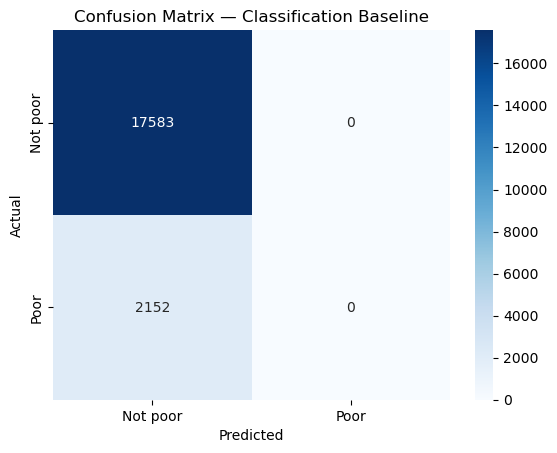

In [243]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Same train/test and preds you already built in Section 12.2
print(classification_report(test["poor_rating"], preds,
                             target_names=["Not poor", "Poor"], digits=4))

cm = confusion_matrix(test["poor_rating"], preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not poor", "Poor"], yticklabels=["Not poor", "Poor"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Classification Baseline")
plt.show()

Same chronological-split discipline, applied to a poor_rating target defined as review_score ≤ 2 (the detractor cutoff from the supervisor's own Getting Started notebook, and the same threshold used for pct_poor_reviews elsewhere in this project). Train/test split: 78,938 / 19,735 orders with a review.

The naive baseline: always predict the majority class, which is "not poor", scores 89.1% accuracy but exactly 0% recall on the poor-rating class: it never once flags an actually-poor order (0 true positives out of 2,152 in the test set). This is why accuracy alone is the wrong metric for this imbalanced target: the baseline looks strong on the metric that doesn't matter and fails completely on the one that does. A real classification model has to beat this on precision/recall, not accuracy.

Note: this baseline is measured at order level as a first pass. The actual classification target ("seller at risk of poor ratings next month") requires a seller-month panel (seller, month t) features predicting poor-rating outcome in month t+1, not a single row per seller. Grouping everything into one row per seller (as done for the regression target) would lose this next-month structure. This baseline will be re-measured at the proper seller-month grain once that panel is built (planned before Report 2).

## 13. EDA-Report1




In [244]:
import matplotlib.pyplot as plt

order_items = olist["order_items"]
order_reviews = olist["order_reviews"].copy()
products = olist["products"]

# Color palette — inspired by the Microsoft Edge logo (teal-green fading to
# blue, plus a deep navy accent)
EDGE_BLUE = "#0F5FBF"
EDGE_NAVY = "#0B3D91"
EDGE_TEAL = "#1DB884"

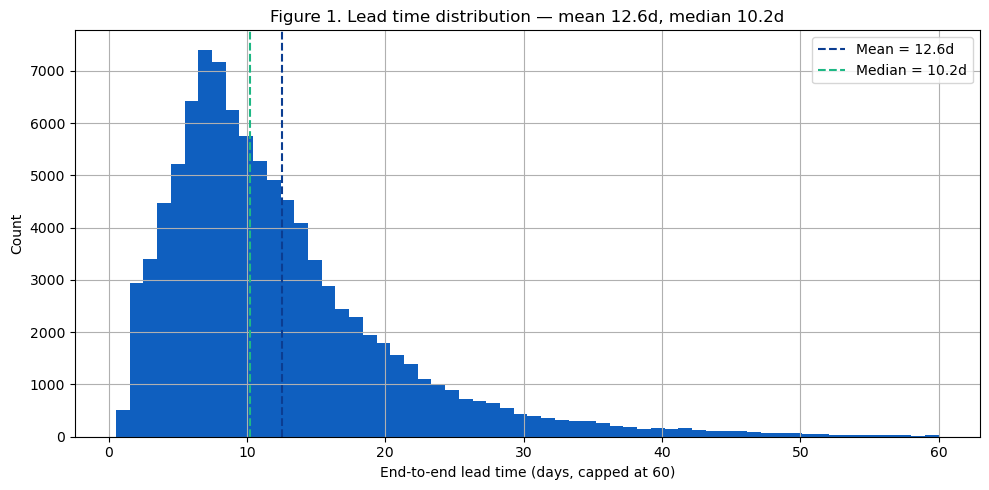

In [245]:
# --- Figure 1: Lead time distribution (delivered orders only) ---
# Reuses the lead_time_days column already added onto `orders` in Section 6.
delivered_lt = orders.loc[orders["order_status"] == "delivered", "lead_time_days"].dropna()
mean_lt = delivered_lt.mean()
median_lt = delivered_lt.median()

fig, ax = plt.subplots(figsize=(10, 5))
delivered_lt[delivered_lt <= 60].hist(bins=60, ax=ax, color=EDGE_BLUE)
ax.axvline(mean_lt, color=EDGE_NAVY, linestyle="--", label=f"Mean = {mean_lt:.1f}d")
ax.axvline(median_lt, color=EDGE_TEAL, linestyle="--", label=f"Median = {median_lt:.1f}d")
ax.set_xlabel("End-to-end lead time (days, capped at 60)")
ax.set_ylabel("Count")
ax.set_title(f"Figure 1. Lead time distribution — mean {mean_lt:.1f}d, median {median_lt:.1f}d")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_lead_time.png", dpi=150)
plt.show()

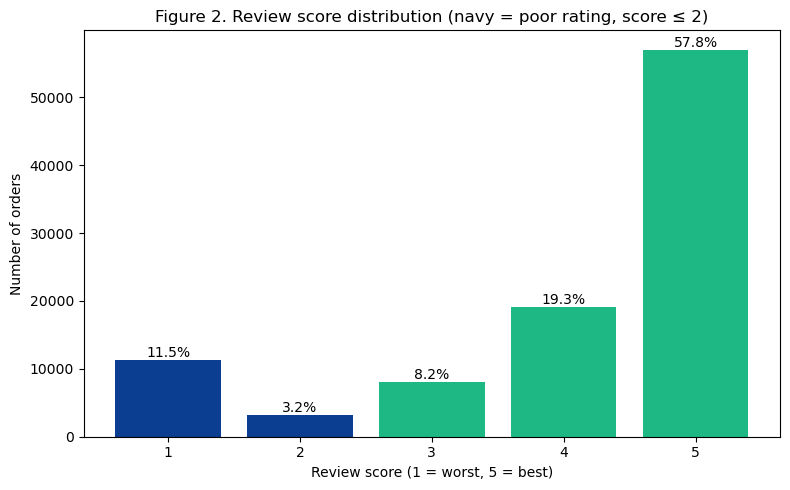

In [246]:
# --- Figure 2: Review score / poor rating distribution ---
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"], errors="coerce")
reviews_sorted = order_reviews.sort_values(["order_id", "review_creation_date"])
review_per_order = reviews_sorted.groupby("order_id").last().reset_index()

score_counts = review_per_order["review_score"].value_counts().sort_index()
pct = (score_counts / score_counts.sum() * 100).round(1)
colors = [EDGE_NAVY if s <= 2 else EDGE_TEAL for s in score_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(score_counts.index, score_counts.values, color=colors)
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{p}%", ha="center", va="bottom")
ax.set_xlabel("Review score (1 = worst, 5 = best)")
ax.set_ylabel("Number of orders")
ax.set_title("Figure 2. Review score distribution (navy = poor rating, score ≤ 2)")
plt.tight_layout()
plt.savefig("fig2_review_scores.png", dpi=150)
plt.show()

In [247]:
# Overall review-score summary (background for the provisional "< 4.0" at-risk rule)
print(f"Reviewed orders: {len(review_per_order):,} | mean review score: {review_per_order['review_score'].mean():.3f} | "
      f"share of 4 or 5: {(review_per_order['review_score'] >= 4).mean():.1%}")

Reviewed orders: 98,673 | mean review score: 4.086 | share of 4 or 5: 77.1%


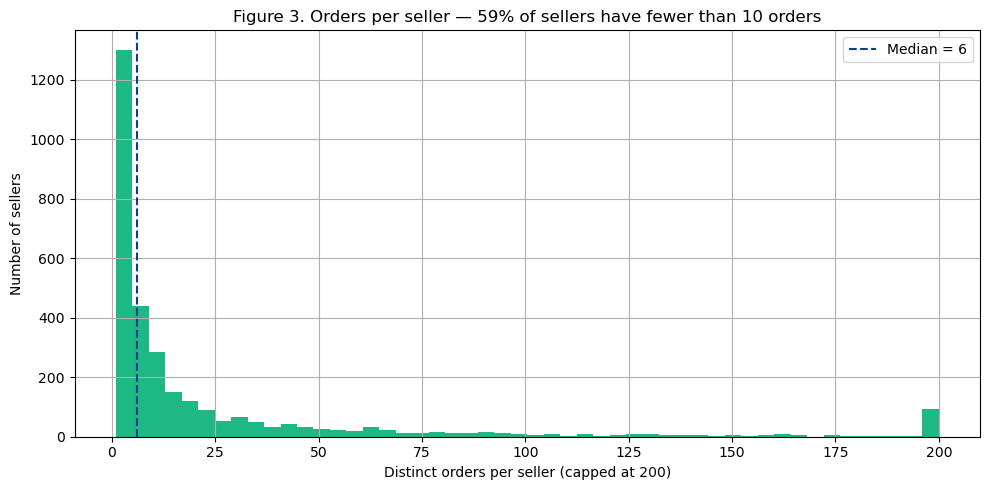

In [248]:
# --- Figure 3: Orders per seller ---
order_seller = order_items[["order_id", "seller_id"]].drop_duplicates()
orders_per_seller = order_seller.groupby("seller_id").size()
pct_under_10 = (orders_per_seller < 10).mean() * 100
median_ops = orders_per_seller.median()

fig, ax = plt.subplots(figsize=(10, 5))
orders_per_seller.clip(upper=200).hist(bins=50, ax=ax, color=EDGE_TEAL)
ax.axvline(median_ops, color=EDGE_NAVY, linestyle="--", label=f"Median = {median_ops:.0f}")
ax.set_xlabel("Distinct orders per seller (capped at 200)")
ax.set_ylabel("Number of sellers")
ax.set_title(f"Figure 3. Orders per seller — {pct_under_10:.0f}% of sellers have fewer than 10 orders")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_orders_per_seller.png", dpi=150)
plt.show()

In [249]:
# Grouped view of Figure 3 (same data, used on Presentation 1 slide 7)
bins   = [0, 1, 2, 3, 5, 9, 19, 49, 99, 199, float("inf")]
labels = ["1", "2", "3", "4-5", "6-9", "10-19", "20-49", "50-99", "100-199", "200+"]
grouped = pd.cut(orders_per_seller, bins=bins, labels=labels).value_counts().sort_index()
print(grouped)
print(f"Total sellers: {grouped.sum():,} | fewer than 10 orders: {(orders_per_seller < 10).sum():,} "
      f"({pct_under_10:.1f}%) | median: {median_ops:.0f}")

1          571
2          353
3          220
4-5        299
6-9        381
10-19      453
20-49      389
50-99      219
100-199    119
200+        91
Name: count, dtype: int64
Total sellers: 3,095 | fewer than 10 orders: 1,824 (58.9%) | median: 6


Fewer than 10 orders: 1,824 sellers (58.9%) | 10+ orders: 1,271 sellers (41.1%) | total 3,095


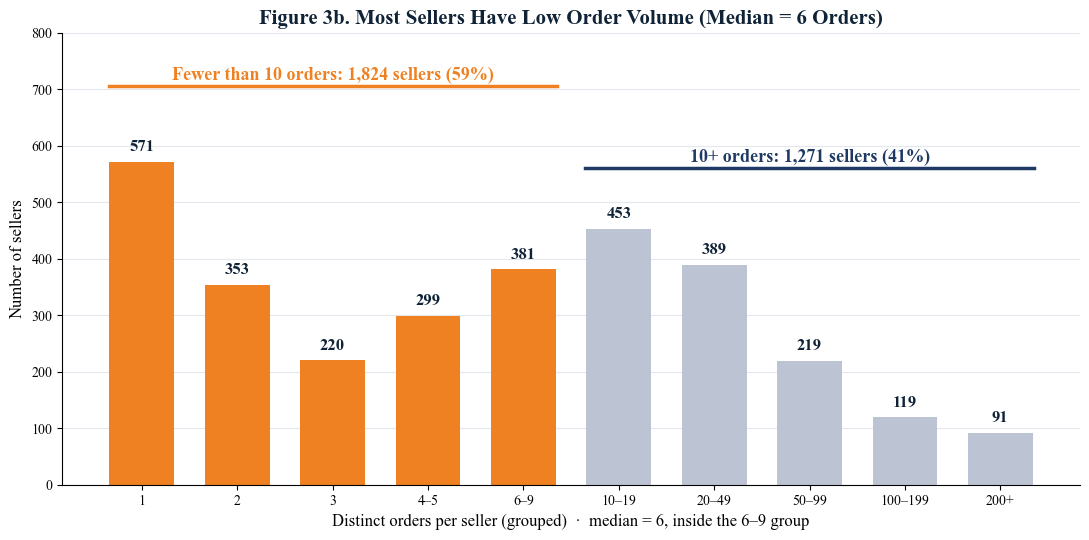

In [250]:
# Figure 3b: slide 7 chart (grouped orders per seller; same data as Figure 3 and the grouped counts above)
ORANGE, GREY, NAVY = "#EF8122", "#BCC4D3", "#1E3A64"
counts = grouped.values                                   # from the "Grouped view of Figure 3" cell
labels = [l.replace("-", "\u2013") for l in grouped.index.astype(str)]
n = len(orders_per_seller)
low = (orders_per_seller < 10).sum()
high = n - low
print(f"Fewer than 10 orders: {low:,} sellers ({low/n:.1%}) | 10+ orders: {high:,} sellers ({high/n:.1%}) | total {n:,}")

with plt.rc_context({"font.family": ["Times New Roman", "serif"]}):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.bar(labels, counts, width=0.68, color=[ORANGE] * 5 + [GREY] * 5)
    for b, v in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, v + 12, f"{v:,}", ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="#0F2236")
    ax.plot([-0.35, 4.35], [705, 705], color=ORANGE, lw=2.5)
    ax.text(2, 718, f"Fewer than 10 orders: {low:,} sellers ({low/n:.0%})",
            ha="center", fontsize=13, fontweight="bold", color=ORANGE)
    ax.plot([4.65, 9.35], [560, 560], color=NAVY, lw=2.5)
    ax.text(7, 573, f"10+ orders: {high:,} sellers ({high/n:.0%})",
            ha="center", fontsize=13, fontweight="bold", color=NAVY)
    ax.set_ylim(0, 800)
    ax.set_ylabel("Number of sellers", fontsize=12)
    ax.set_xlabel(f"Distinct orders per seller (grouped)  \u00b7  median = {median_ops:.0f}, inside the 6\u20139 group", fontsize=12)
    ax.set_title(f"Figure 3b. Most Sellers Have Low Order Volume (Median = {median_ops:.0f} Orders)",
                 fontsize=15, fontweight="bold", color="#0F2236")
    ax.grid(axis="y", color="#E3E7EE"); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    plt.savefig("fig3b_orders_per_seller_grouped.png", dpi=150)
    plt.show()

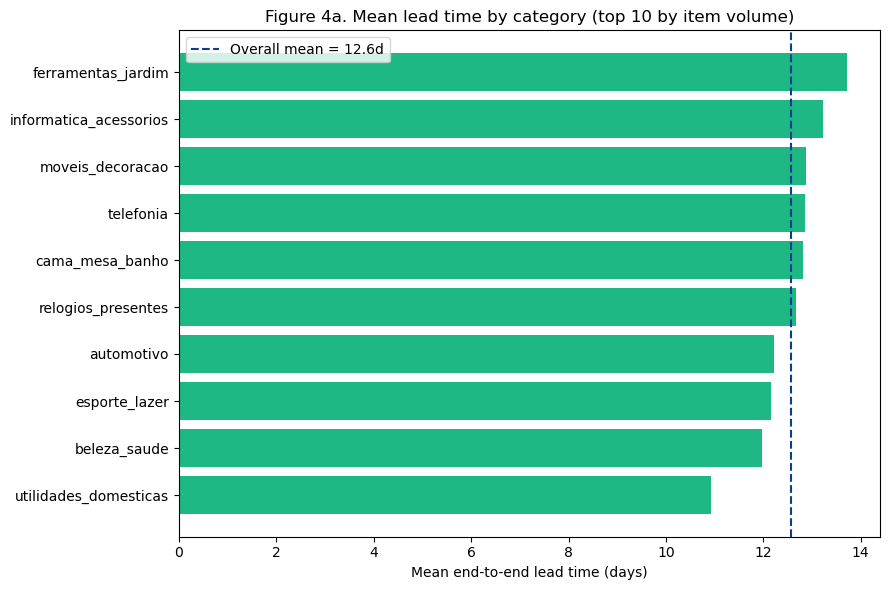

In [251]:
# --- Figure 4a: Mean lead time by category ---
item_cat = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
item_cat = item_cat.merge(orders[["order_id", "lead_time_days"]], on="order_id", how="left")

cat_summary = (
    item_cat.groupby("product_category_name")
    .agg(n_items=("order_id", "count"), mean_lead_time=("lead_time_days", "mean"))
    .sort_values("n_items", ascending=False)
    .head(10)
    .sort_values("mean_lead_time")
)
overall_mean = delivered_lt.mean()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cat_summary.index, cat_summary["mean_lead_time"], color=EDGE_TEAL)
ax.axvline(overall_mean, color=EDGE_NAVY, linestyle="--", label=f"Overall mean = {overall_mean:.1f}d")
ax.set_xlabel("Mean end-to-end lead time (days)")
ax.set_title("Figure 4a. Mean lead time by category (top 10 by item volume)")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_category_lead_time.png", dpi=150)
plt.show()

In [252]:
# Values behind Figure 4a (top 10 categories by item volume)
print(cat_summary.round(1))
print(f"Range: {cat_summary['mean_lead_time'].min():.1f} to {cat_summary['mean_lead_time'].max():.1f} days "
      f"(difference {cat_summary['mean_lead_time'].max() - cat_summary['mean_lead_time'].min():.1f})")

                        n_items  mean_lead_time
product_category_name                          
utilidades_domesticas      6964           10.90
beleza_saude               9670           12.00
esporte_lazer              8641           12.20
automotivo                 4235           12.20
relogios_presentes         5991           12.70
cama_mesa_banho           11115           12.80
telefonia                  4545           12.90
moveis_decoracao           8334           12.90
informatica_acessorios     7827           13.20
ferramentas_jardim         4347           13.70
Range: 10.9 to 13.7 days (difference 2.8)


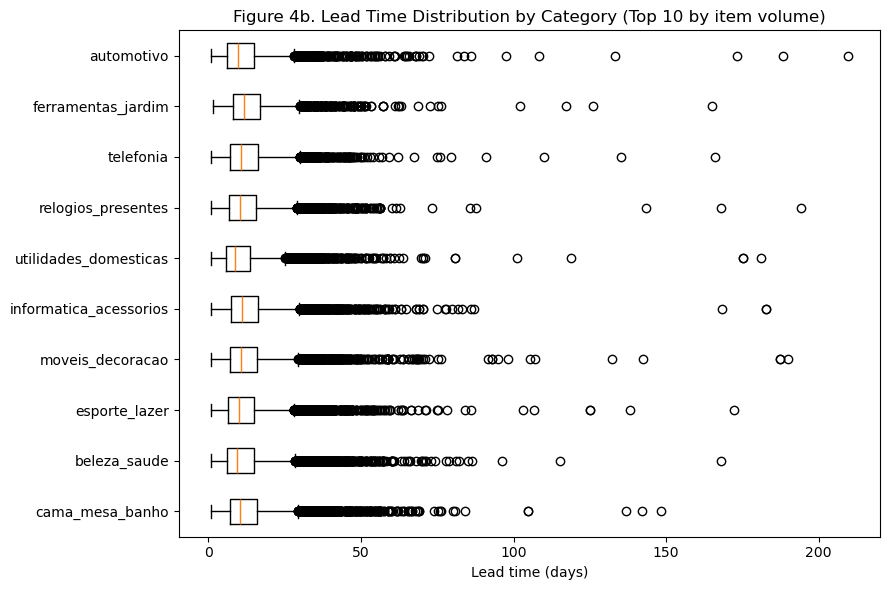

In [251]:
# --- Figure 4b: Lead time distribution by category (companion to Figure 4a) ---
top10 = item_cat["product_category_name"].value_counts().head(10).index
data_by_cat = [
    item_cat.loc[item_cat["product_category_name"] == c, "lead_time_days"].dropna()
    for c in top10
]
plt.figure(figsize=(9, 6))
plt.boxplot(data_by_cat, tick_labels=top10, vert=False)
plt.xlabel("Lead time (days)")
plt.title("Figure 4b. Lead Time Distribution by Category (Top 10 by item volume)")
plt.tight_layout()
plt.show()

## 14. Feature relationships (Report 2 prep)

Exploratory check on the cleaned seller-level features before Report 2 modelling — not one of the four Report 1 EDA figures above, which are tied to specific decisions already made in this report.




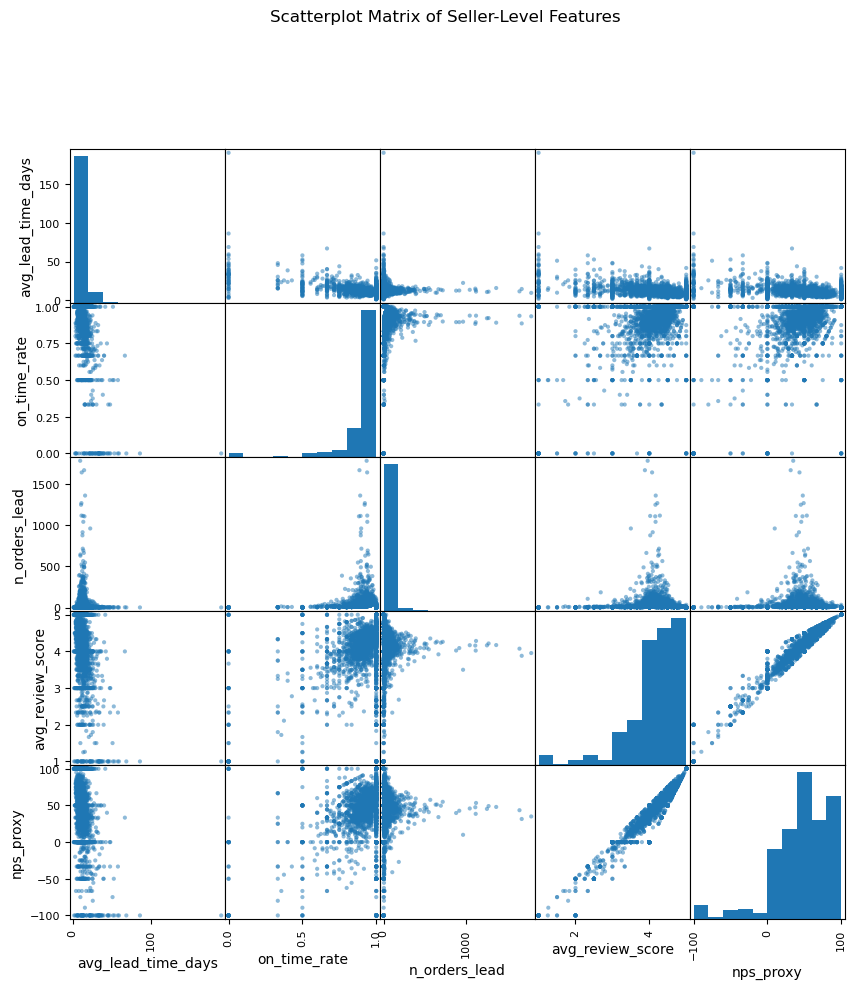

In [252]:
from pandas.plotting import scatter_matrix

numeric_cols = ["avg_lead_time_days", "on_time_rate", "n_orders_lead",
                "avg_review_score", "nps_proxy"]
scatter_matrix(clean_seller_table[numeric_cols], figsize=(10, 10), diagonal="hist")
plt.suptitle("Scatterplot Matrix of Seller-Level Features", y=1.02)
plt.show()